# TCS iON AIP 135
# A Neural Network Approach to Analyse Customer Metrics and Predict Buying Trends

**Student:** Nehal Parate | **SRN:** 31251194  
**Mentor:** Dr. Raeesa Bashir  
**Department:** Mathematics and Statistics, Faculty of Science and Technology  
**University:** Vishwakarma University, Pune | **AY:** 2025-26

---
**Target Variable:** `churned` (Yes = 1 / No = 0) — Binary Churn Classification  
**Model:** MLPClassifier (Multilayer Perceptron Neural Network) — Scikit-learn  
**Dataset:** Retail Sales and Customer Behavior Dataset (10,000 rows, 78 columns)

---
# CHAPTER 1 — DATA PRE-PROCESSING
## 1.1 Setup & Initialization — Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn graphviz openpyxl joblib pyspark findspark

In [2]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn graphviz openpyxl joblib pyspark findspark

# ─── Standard Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
import time
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ─── PySpark ──────────────────────────────────────────────────────────────────
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler as SparkScaler
)
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# ─── Graphviz ─────────────────────────────────────────────────────────────────
from graphviz import Digraph

import sklearn, pyspark
print('=' * 55)
print('  Libraries Loaded Successfully')
print('=' * 55)
print(f'  Python      : {__import__("sys").version.split()[0]}')
print(f'  Pandas      : {pd.__version__}')
print(f'  NumPy       : {np.__version__}')
print(f'  Scikit-learn: {sklearn.__version__}')
print(f'  PySpark     : {pyspark.__version__}')

# ─── PySpark Ensemble Models ──────────────────────────────────────────────────
from pyspark.ml.classification import (
    RandomForestClassifier,
    GBTClassifier,
    MultilayerPerceptronClassifier
)
from pyspark.ml.feature import ChiSqSelector


  Libraries Loaded Successfully
  Python      : 3.12.13
  Pandas      : 2.2.2
  NumPy       : 2.0.2
  Scikit-learn: 1.6.1
  PySpark     : 4.0.2


## 1.2 Load Dataset

In [3]:
import pandas as pd
from google.colab import files

# Upload file from your system
uploaded = files.upload()

# Get uploaded file name automatically
file_name = list(uploaded.keys())[0]

# Load CSV dataset (correct function)
df = pd.read_csv(file_name)

# Optional: save a copy (same file or renamed)
df.to_csv('retail_customer_data.csv', index=False)

print('=' * 50)
print('  Dataset Loaded Successfully')
print('=' * 50)
print(f'  Rows      : {df.shape[0]:,}')
print(f'  Columns   : {df.shape[1]}')
print(f'  CSV saved : retail_customer_data.csv')
print()

df.head()

Saving Shorted_Data (1).csv to Shorted_Data (1).csv
  Dataset Loaded Successfully
  Rows      : 10,000
  Columns   : 78
  CSV saved : retail_customer_data.csv



,customer_id,age,gender,income_bracket,loyalty_program,membership_years,churned,marital_status,number_of_children,education_level,...,distance_to_store,holiday_season,season,weekend,customer_support_calls,email_subscriptions,app_usage,website_visits,social_media_engagement,days_since_last_purchase
0,1,56,Other,High,No,0,No,Divorced,3,Bachelor's,...,33.21,No,Spring,Yes,5,No,High,30,High,40
1,2,69,Female,Medium,No,2,No,Married,2,PhD,...,62.56,No,Summer,Yes,6,No,High,40,Medium,338
2,3,46,Female,Low,No,5,No,Married,3,Bachelor's,...,83.04,Yes,Winter,Yes,2,Yes,Low,89,Medium,61
3,4,32,Female,Low,No,0,No,Divorced,2,Master's,...,50.43,Yes,Winter,No,12,No,Low,12,Low,42
4,5,60,Female,Low,Yes,7,Yes,Divorced,2,Bachelor's,...,36.55,Yes,Summer,Yes,3,No,Medium,31,Low,242


## 1.3 Dataset Description & Schema

In [4]:
print('Dataset Schema (Column Types):')
df.info()
print()
print('Statistical Summary:')
df.describe().T

Dataset Schema (Column Types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 78 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                10000 non-null  int64  
 1   age                        10000 non-null  int64  
 2   gender                     10000 non-null  object 
 3   income_bracket             10000 non-null  object 
 4   loyalty_program            10000 non-null  object 
 5   membership_years           10000 non-null  int64  
 6   churned                    10000 non-null  object 
 7   marital_status             10000 non-null  object 
 8   number_of_children         10000 non-null  int64  
 9   education_level            10000 non-null  object 
 10  occupation                 10000 non-null  object 
 11  transaction_id             10000 non-null  int64  
 12  transaction_date           10000 non-null  object 
 13  product_id      

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,5000.500000,2886.895680,1.00,2500.7500,5000.500,7500.2500,10000.00
age,10000.0,48.798400,17.903223,18.00,34.0000,49.000,64.0000,79.00
membership_years,10000.0,4.541400,2.859773,0.00,2.0000,5.000,7.0000,9.00
number_of_children,10000.0,2.001900,1.420879,0.00,1.0000,2.000,3.0000,4.00
transaction_id,10000.0,499921.757900,287559.323564,2.00,251458.7500,496914.000,745714.0000,999955.00
product_id,10000.0,5002.320800,2885.682875,1.00,2517.2500,5016.000,7488.0000,9997.00
quantity,10000.0,4.972000,2.583773,1.00,3.0000,5.000,7.0000,9.00
unit_price,10000.0,501.018185,285.853682,1.08,253.7475,505.980,745.0750,999.93
discount_applied,10000.0,0.250592,0.144735,0.00,0.1200,0.250,0.3800,0.50
transaction_hour,10000.0,11.528300,6.996978,0.00,5.0000,11.000,18.0000,23.00


---
# CHAPTER 2 — EXPLORATORY DATA ANALYSIS (EDA)
## 2.1 Data Quality & Target Variable Distribution

In [5]:
# ─── Missing Values Audit ─────────────────────────────────────────────────────
print('Missing Value Audit:')
missing = df.isnull().sum()
print(f'  Total missing values: {missing.sum()}')
if missing.sum() == 0:
    print('  ✓ Zero null values — full dataset usable without imputation')
else:
    print(missing[missing > 0])

print()
print('Target Variable Distribution (churned):')
churn_counts = df['churned'].value_counts()
churn_pct    = df['churned'].value_counts(normalize=True) * 100
for val in churn_counts.index:
    print(f'  {val}: {churn_counts[val]:,} ({churn_pct[val]:.1f}%)')

Missing Value Audit:
  Total missing values: 0
  ✓ Zero null values — full dataset usable without imputation

Target Variable Distribution (churned):
  Yes: 5,070 (50.7%)
  No: 4,930 (49.3%)


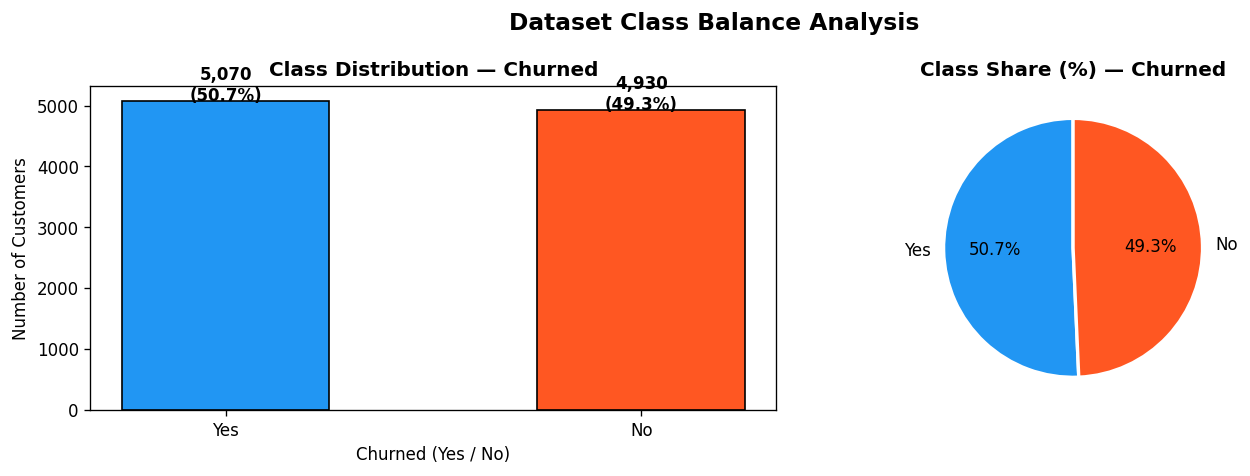

Saved: img1_class_balance.png


In [6]:
# ─── Class Balance Analysis (matching Abhinav's Img 1 & Img 2 style) ──────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Class Balance Analysis', fontsize=14, fontweight='bold')

# Bar chart — class distribution
colors_cls = ['#2196F3', '#FF5722']
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=colors_cls, edgecolor='black', width=0.5)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Class Distribution — Churned', fontweight='bold')
axes[0].set_xlabel('Churned (Yes / No)')
axes[0].set_ylabel('Number of Customers')

# Pie chart — class share
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=colors_cls,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Share (%) — Churned', fontweight='bold')

plt.tight_layout()
plt.savefig('img1_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img1_class_balance.png')

## 2.2 Income Bracket & Gender vs Churn Behaviour

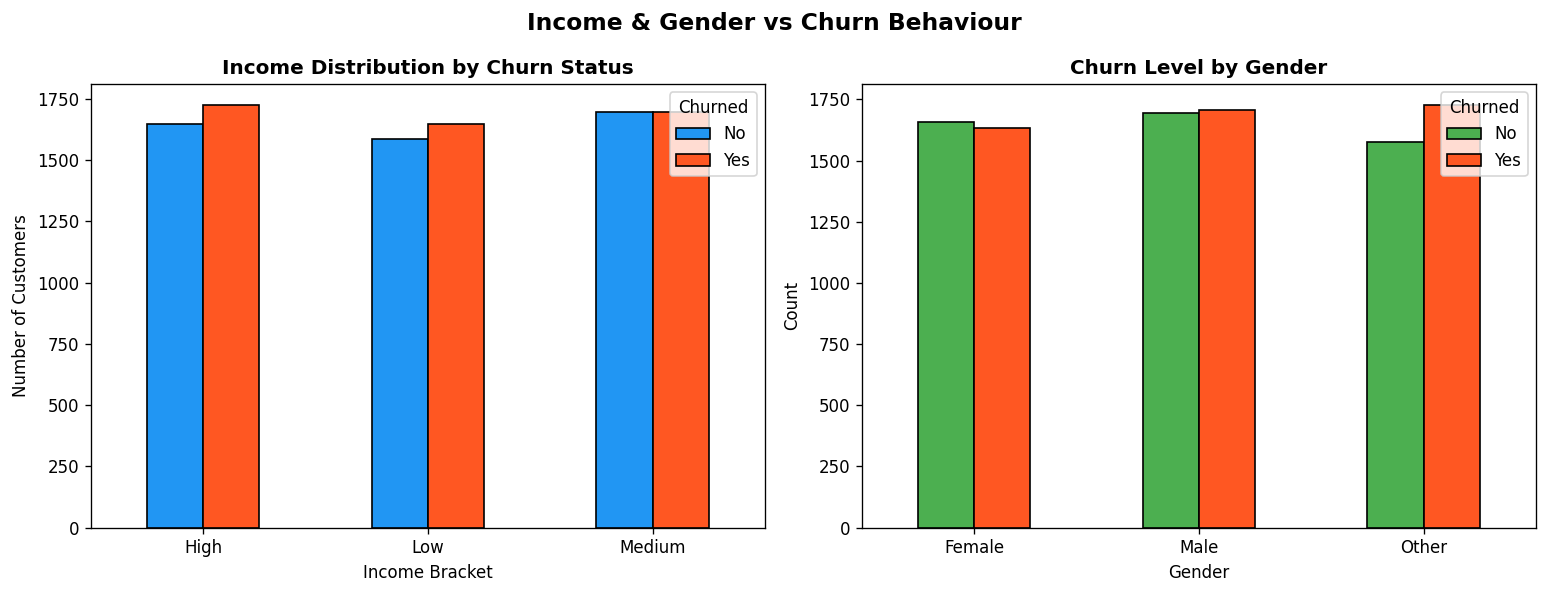

Saved: img2_income_gender_churn.png


In [7]:
# ─── Income & Gender Analysis (matching Abhinav's Img 3 & Img 4) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Income & Gender vs Churn Behaviour', fontsize=14, fontweight='bold')

# Income bracket vs churn — box plot style via grouped bar
inc_churn = df.groupby(['income_bracket','churned']).size().unstack(fill_value=0)
inc_churn.plot(kind='bar', ax=axes[0], color=['#2196F3','#FF5722'], edgecolor='black')
axes[0].set_title('Income Distribution by Churn Status', fontweight='bold')
axes[0].set_xlabel('Income Bracket')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Churned')

# Gender vs churn
gen_churn = df.groupby(['gender','churned']).size().unstack(fill_value=0)
gen_churn.plot(kind='bar', ax=axes[1], color=['#4CAF50','#FF5722'], edgecolor='black')
axes[1].set_title('Churn Level by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Churned')

plt.tight_layout()
plt.savefig('img2_income_gender_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img2_income_gender_churn.png')

## 2.3 Store Location & Product Category Analysis

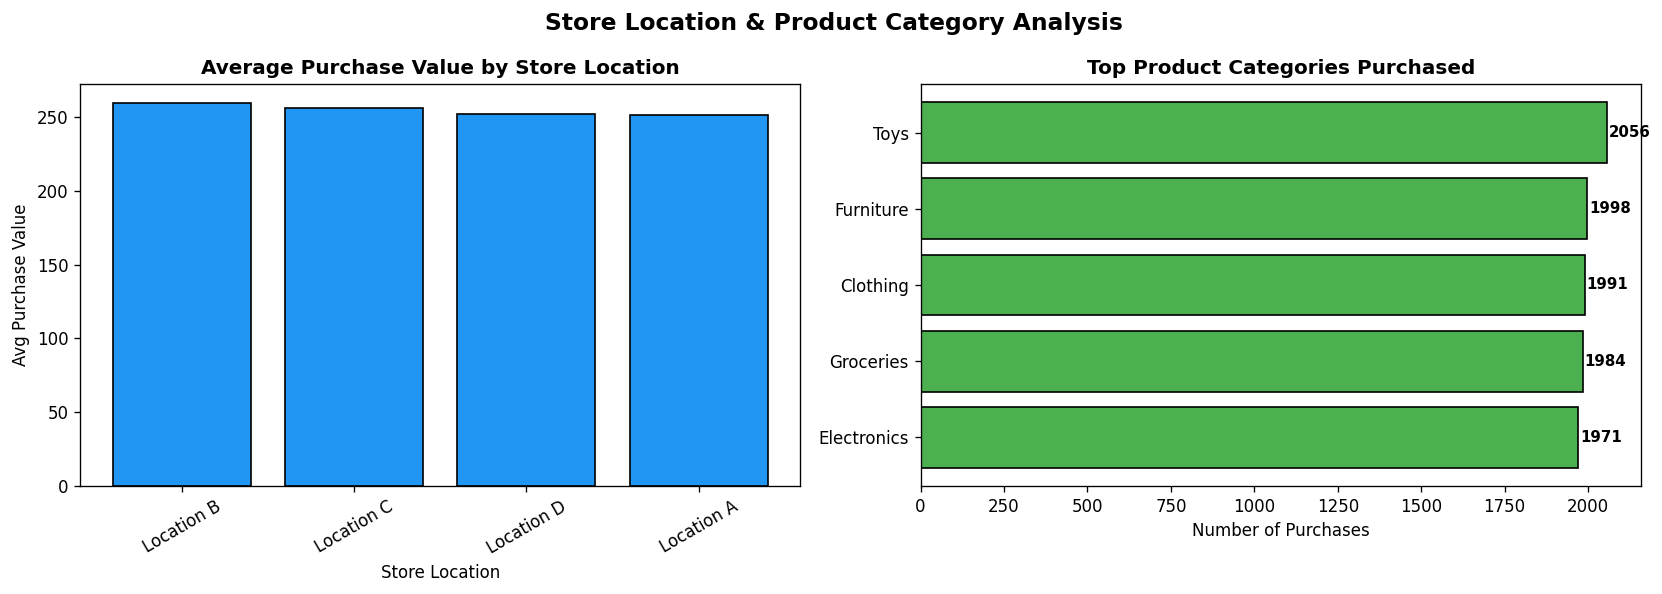

Saved: img3_location_category.png


In [8]:
# ─── Location & Product Category (matching Abhinav's Img 5 & Img 6) ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Store Location & Product Category Analysis', fontsize=14, fontweight='bold')

# Avg purchase value by store location
loc_avg = df.groupby('store_location')['avg_purchase_value'].mean().sort_values(ascending=False)
axes[0].bar(loc_avg.index, loc_avg.values, color='#2196F3', edgecolor='black')
axes[0].set_title('Average Purchase Value by Store Location', fontweight='bold')
axes[0].set_xlabel('Store Location')
axes[0].set_ylabel('Avg Purchase Value')
axes[0].tick_params(axis='x', rotation=30)

# Top product categories by count
cat_counts = df['product_category'].value_counts().head(8)
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1],
             color='#4CAF50', edgecolor='black')
for i, (idx, val) in enumerate(zip(cat_counts.index[::-1], cat_counts.values[::-1])):
    axes[1].text(val + 5, i, str(val), va='center', fontweight='bold', fontsize=9)
axes[1].set_title('Top Product Categories Purchased', fontweight='bold')
axes[1].set_xlabel('Number of Purchases')

plt.tight_layout()
plt.savefig('img3_location_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img3_location_category.png')

## 2.4 Scatter Plot Analysis — Feature Relationships

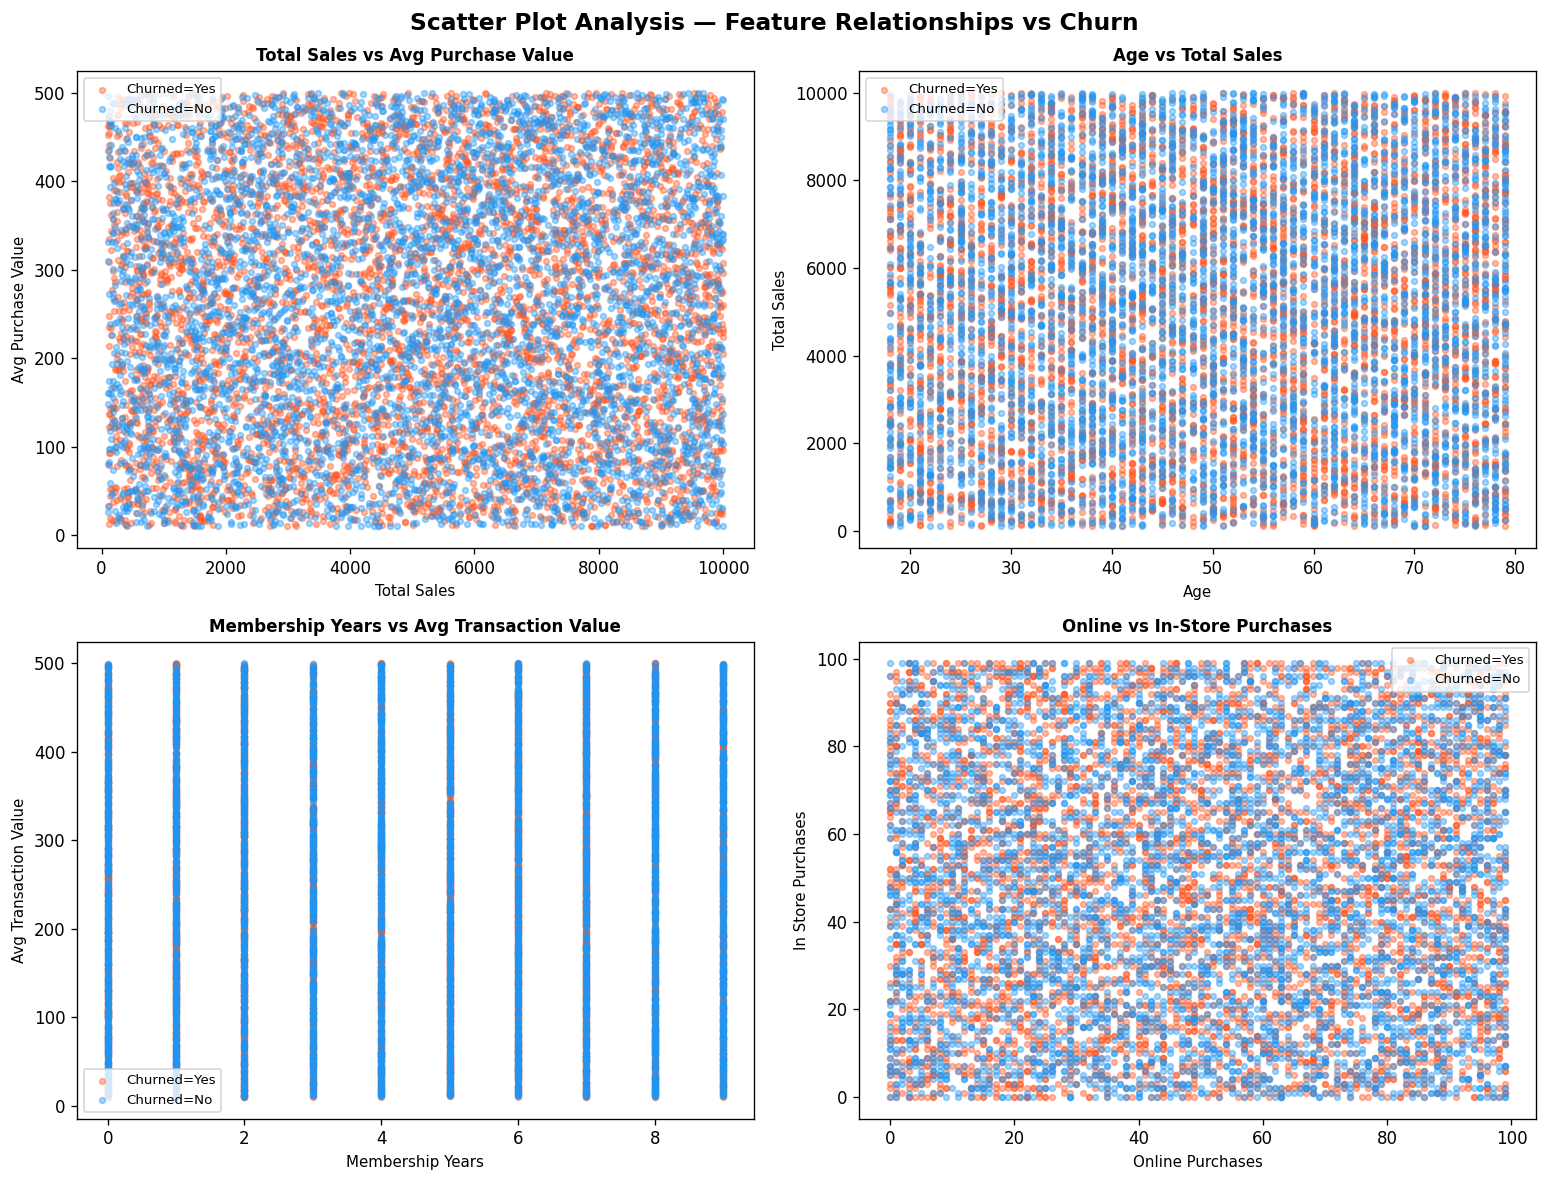

Saved: img4_scatter_analysis.png


In [9]:
# ─── Scatter Plots (matching Abhinav's Img 7) ─────────────────────────────────
color_map = {'Yes': '#FF5722', 'No': '#2196F3'}
colors_scatter = df['churned'].map(color_map)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Scatter Plot Analysis — Feature Relationships vs Churn', fontsize=14, fontweight='bold')

scatter_pairs = [
    ('total_sales',        'avg_purchase_value',  'Total Sales vs Avg Purchase Value'),
    ('age',                'total_sales',          'Age vs Total Sales'),
    ('membership_years',   'avg_transaction_value','Membership Years vs Avg Transaction Value'),
    ('online_purchases',   'in_store_purchases',   'Online vs In-Store Purchases'),
]

for ax, (x_col, y_col, title) in zip(axes.flat, scatter_pairs):
    for churn_val, color in color_map.items():
        mask = df['churned'] == churn_val
        ax.scatter(df[mask][x_col], df[mask][y_col],
                   alpha=0.4, c=color, label=f'Churned={churn_val}', s=12)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel(x_col.replace('_',' ').title(), fontsize=9)
    ax.set_ylabel(y_col.replace('_',' ').title(), fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('img4_scatter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img4_scatter_analysis.png')

## 2.5 Correlation Matrix of Numerical Features

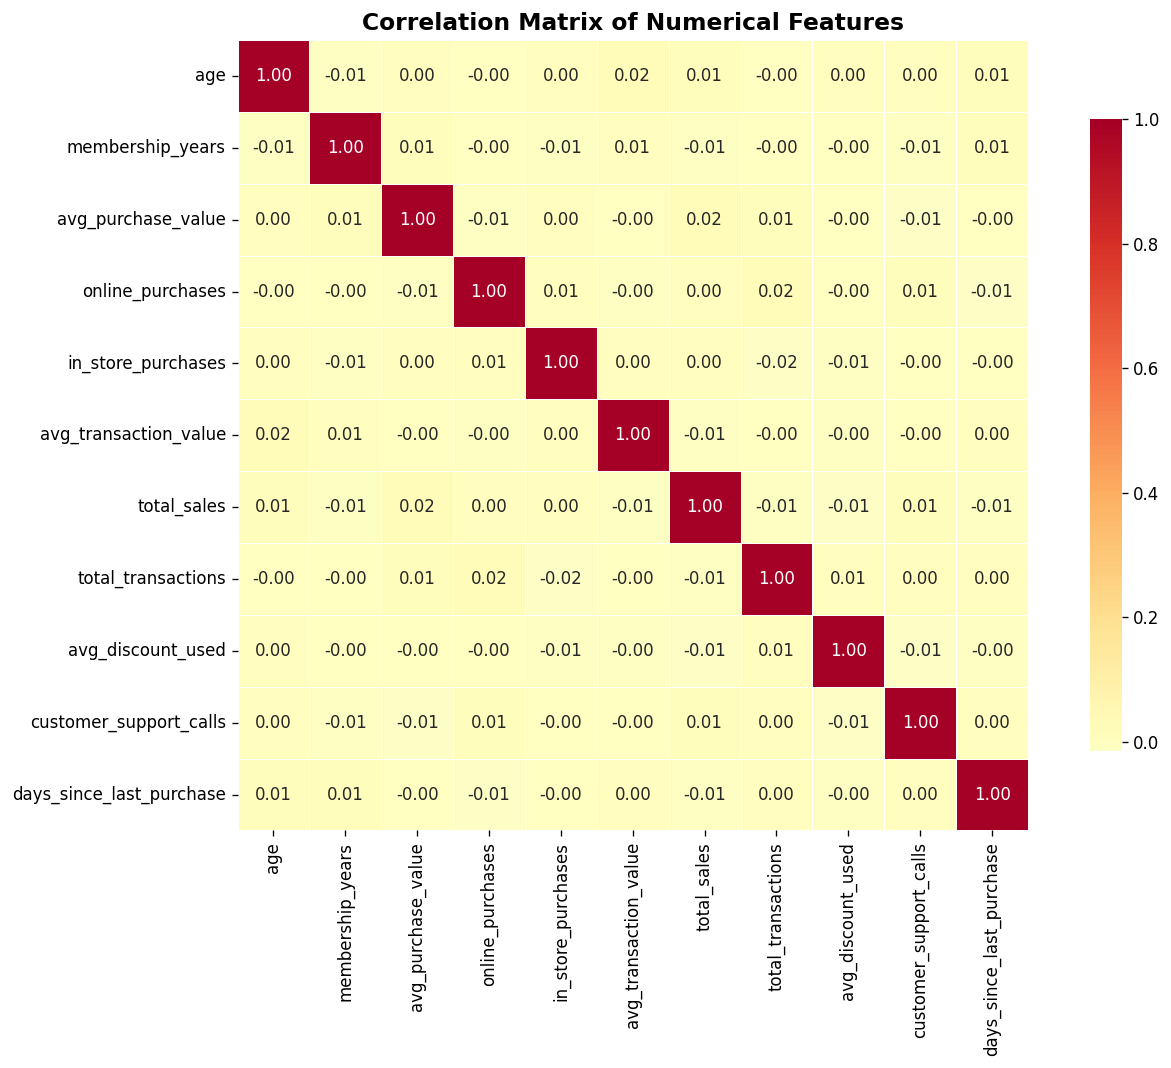

Saved: img5_correlation_matrix.png


In [10]:
# ─── Correlation Matrix (matching Abhinav's Img 8) ────────────────────────────
num_cols_corr = [
    'age', 'membership_years', 'avg_purchase_value',
    'online_purchases', 'in_store_purchases',
    'avg_transaction_value', 'total_sales',
    'total_transactions', 'avg_discount_used',
    'customer_support_calls', 'days_since_last_purchase'
]
corr = df[num_cols_corr].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('img5_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img5_correlation_matrix.png')

## 2.6 Loyalty Program, Purchase Frequency & Customer Segmentation

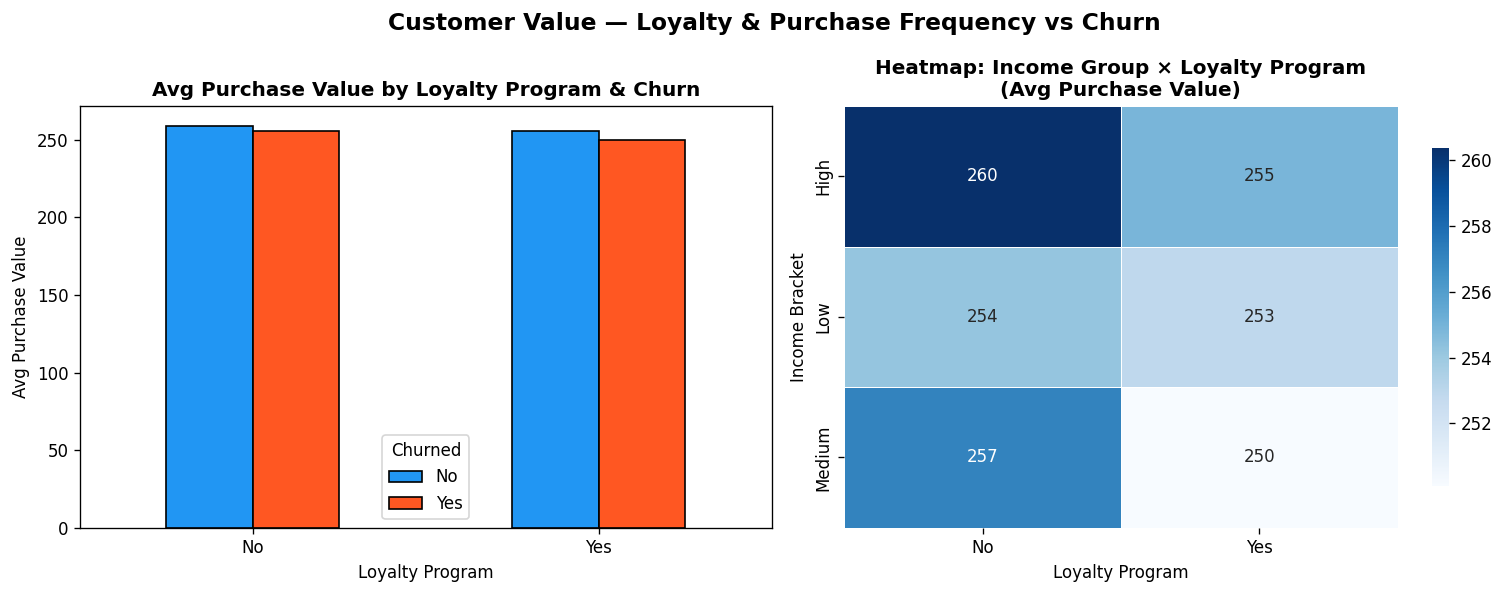

Saved: img6_loyalty_heatmap.png


In [11]:
# ─── Loyalty & Purchase Frequency (matching Abhinav's Img 9 & Img 10) ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Customer Value — Loyalty & Purchase Frequency vs Churn', fontsize=14, fontweight='bold')

# Avg purchase value by loyalty × churn
loy_churn = df.groupby(['loyalty_program','churned'])['avg_purchase_value'].mean().unstack()
loy_churn.plot(kind='bar', ax=axes[0], color=['#2196F3','#FF5722'], edgecolor='black')
axes[0].set_title('Avg Purchase Value by Loyalty Program & Churn', fontweight='bold')
axes[0].set_xlabel('Loyalty Program')
axes[0].set_ylabel('Avg Purchase Value')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Churned')

# Heatmap: purchase_frequency × loyalty_program — avg purchase value
hm_data = df.groupby(['income_bracket','loyalty_program'])['avg_purchase_value'].mean().unstack()
sns.heatmap(hm_data, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink':0.8})
axes[1].set_title('Heatmap: Income Group × Loyalty Program\n(Avg Purchase Value)', fontweight='bold')
axes[1].set_xlabel('Loyalty Program')
axes[1].set_ylabel('Income Bracket')

plt.tight_layout()
plt.savefig('img6_loyalty_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img6_loyalty_heatmap.png')

## 2.7 Promotion Effectiveness & Seasonal Analysis

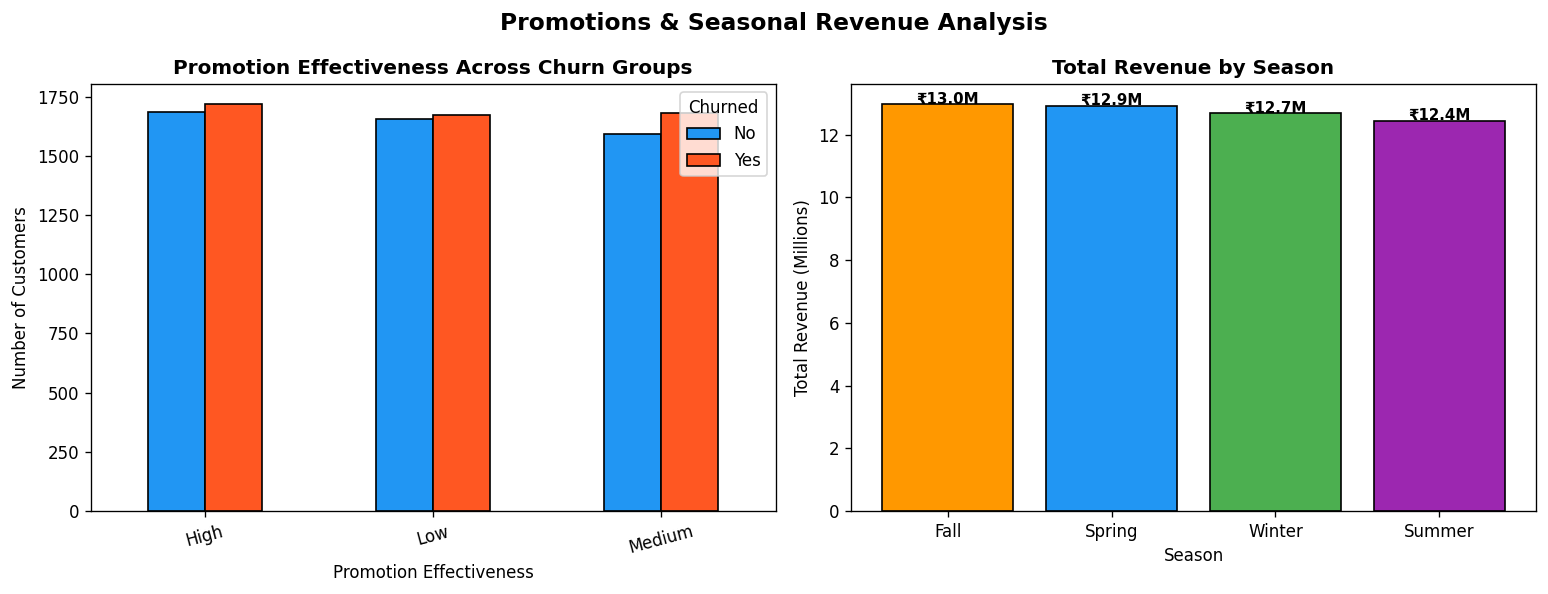

Saved: img7_promotion_season.png


In [12]:
# ─── Promotion & Season Analysis (matching Abhinav's Img 11 & Img 12) ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Promotions & Seasonal Revenue Analysis', fontsize=14, fontweight='bold')

# Promotion effectiveness across churn groups
promo_churn = df.groupby(['promotion_effectiveness','churned']).size().unstack(fill_value=0)
promo_churn.plot(kind='bar', ax=axes[0], color=['#2196F3','#FF5722'], edgecolor='black')
axes[0].set_title('Promotion Effectiveness Across Churn Groups', fontweight='bold')
axes[0].set_xlabel('Promotion Effectiveness')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Churned')

# Total sales by season — revenue contribution
season_rev = df.groupby('season')['total_sales'].sum().sort_values(ascending=False)
bars2 = axes[1].bar(season_rev.index, season_rev.values / 1e6,
                    color=['#FF9800','#2196F3','#4CAF50','#9C27B0'], edgecolor='black')
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'₹{bar.get_height():.1f}M', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('Total Revenue by Season', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Total Revenue (Millions)')

plt.tight_layout()
plt.savefig('img7_promotion_season.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img7_promotion_season.png')

---
# CHAPTER 3 — MODEL BUILDING & IMPLEMENTATION
## 3.0 Initialise SparkSession (Google Colab)


In [13]:
# ─── SparkSession (Colab-safe) ────────────────────────────────────────────────
spark = (SparkSession.builder
         .appName("TCS_iON_AIP135_ChurnPrediction")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.ui.showConsoleProgress", "false")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

print('SparkSession initialised')
print(f'  Spark version : {spark.version}')
print(f'  App name      : {spark.sparkContext.appName}')
print(f'  Master        : {spark.sparkContext.master}')


SparkSession initialised
  Spark version : 4.0.2
  App name      : TCS_iON_AIP135_ChurnPrediction
  Master        : local[*]


## 3.1 Feature Engineering & PySpark Pipeline

In [14]:
# ─── Feature Selection ────────────────────────────────────────────────────────
categorical_cols = [
    'gender', 'income_bracket', 'loyalty_program',
    'marital_status', 'education_level', 'occupation',
    'product_category', 'payment_method', 'store_location',
    'purchase_frequency', 'season', 'promotion_effectiveness'
]

numerical_cols = [
    'age', 'membership_years', 'number_of_children',
    'quantity', 'unit_price', 'discount_applied',
    'avg_purchase_value', 'avg_discount_used',
    'online_purchases', 'in_store_purchases',
    'avg_items_per_transaction', 'avg_transaction_value',
    'total_returned_items', 'total_returned_value',
    'total_sales', 'total_transactions', 'total_items_purchased',
    'total_discounts_received', 'avg_spent_per_category',
    'product_rating', 'product_review_count', 'product_return_rate',
    'distance_to_store', 'customer_support_calls',
    'website_visits', 'days_since_last_purchase'
]

TARGET = 'churned'

print('Feature Engineering Summary:')
print(f'  Categorical features : {len(categorical_cols)}')
print(f'  Numerical features   : {len(numerical_cols)}')
print(f'  Total features       : {len(categorical_cols)+len(numerical_cols)}')
print(f'  Target variable      : {TARGET} (Yes=1, No=0)')


Feature Engineering Summary:
  Categorical features : 12
  Numerical features   : 26
  Total features       : 38
  Target variable      : churned (Yes=1, No=0)


In [15]:
# ─── Convert Pandas → Spark DataFrame ────────────────────────────────────────
all_cols   = categorical_cols + numerical_cols + [TARGET]
df_model   = df[all_cols].copy().dropna()

# Convert target to integer label (Yes→1, No→0)
df_model['label'] = (df_model[TARGET] == 'Yes').astype(int)

# Create Spark DataFrame
spark_df = spark.createDataFrame(df_model)
spark_df = spark_df.withColumn('label', F.col('label').cast('double'))

print('Spark DataFrame created:')
print(f'  Rows      : {spark_df.count():,}')
print(f'  Columns   : {len(spark_df.columns)}')
spark_df.printSchema()


Spark DataFrame created:
  Rows      : 10,000
  Columns   : 40
root
 |-- gender: string (nullable = true)
 |-- income_bracket: string (nullable = true)
 |-- loyalty_program: string (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- education_level: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- store_location: string (nullable = true)
 |-- purchase_frequency: string (nullable = true)
 |-- season: string (nullable = true)
 |-- promotion_effectiveness: string (nullable = true)
 |-- age: long (nullable = true)
 |-- membership_years: long (nullable = true)
 |-- number_of_children: long (nullable = true)
 |-- quantity: long (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- discount_applied: double (nullable = true)
 |-- avg_purchase_value: double (nullable = true)
 |-- avg_discount_used: double (nullable = true)
 |-- online_purchases: long (

In [16]:
# ─── PySpark Pipeline: StringIndexer → OneHotEncoder → VectorAssembler ───────
#
#  StringIndexer  : converts each categorical string column to a numeric index
#  OneHotEncoder  : converts each index to a sparse binary vector
#  VectorAssembler: merges all feature vectors into a single 'features' vector
#  SparkScaler    : StandardScaler equivalent for the assembled feature vector

# 1. StringIndexer — one per categorical column
string_indexers = [
    StringIndexer(inputCol=col, outputCol=f'{col}_idx', handleInvalid='keep')
    for col in categorical_cols
]

# 2. OneHotEncoder — encode indexed columns
ohe_input_cols  = [f'{col}_idx' for col in categorical_cols]
ohe_output_cols = [f'{col}_ohe' for col in categorical_cols]

ohe = OneHotEncoder(
    inputCols  = ohe_input_cols,
    outputCols = ohe_output_cols,
    handleInvalid='keep'
)

# 3. VectorAssembler — merge OHE vectors + numerical columns
assembler = VectorAssembler(
    inputCols  = ohe_output_cols + numerical_cols,
    outputCol  = 'raw_features',
    handleInvalid='keep'
)

# 4. StandardScaler — normalise feature vector (critical for MLP convergence)
spark_scaler = SparkScaler(
    inputCol  = 'raw_features',
    outputCol = 'features',
    withMean  = False,   # sparse-safe (False avoids dense conversion)
    withStd   = True
)

print('PySpark Pipeline stages defined:')
print(f'  Stage 1 : {len(string_indexers)} × StringIndexer  (categorical → numeric index)')
print(f'  Stage 2 : 1 × OneHotEncoder      ({len(categorical_cols)} columns → binary vectors)')
print(f'  Stage 3 : 1 × VectorAssembler    (OHE + {len(numerical_cols)} numerical → raw_features)')
print(f'  Stage 4 : 1 × StandardScaler     (raw_features → scaled features)')


PySpark Pipeline stages defined:
  Stage 1 : 12 × StringIndexer  (categorical → numeric index)
  Stage 2 : 1 × OneHotEncoder      (12 columns → binary vectors)
  Stage 3 : 1 × VectorAssembler    (OHE + 26 numerical → raw_features)
  Stage 4 : 1 × StandardScaler     (raw_features → scaled features)


## 3.2 Train/Test Split (Spark) & Pipeline Fit

In [17]:
# ─── 80/20 Stratified Split in Spark ─────────────────────────────────────────
train_spark, test_spark = spark_df.randomSplit([0.80, 0.20], seed=42)

print('Train/Test Split:')
print(f'  Training rows : {train_spark.count():,} (≈80%)')
print(f'  Testing rows  : {test_spark.count():,} (≈20%)')

# ─── Fit preprocessing pipeline on train set ─────────────────────────────────
prep_pipeline = Pipeline(stages=string_indexers + [ohe, assembler, spark_scaler])
prep_model    = prep_pipeline.fit(train_spark)

train_prepped = prep_model.transform(train_spark)
test_prepped  = prep_model.transform(test_spark)

# Keep only label + features for MLP
train_final = train_prepped.select('label','features')
test_final  = test_prepped.select('label','features')

# Also keep pandas copies for sklearn plotting later
train_pd = train_prepped.toPandas()
test_pd  = test_prepped.toPandas()

print()
print('Preprocessing pipeline fitted and applied.')
print('  StringIndexer  ✓  OneHotEncoder  ✓  VectorAssembler  ✓  StandardScaler  ✓')


Train/Test Split:
  Training rows : 8,053 (≈80%)
  Testing rows  : 1,947 (≈20%)

Preprocessing pipeline fitted and applied.
  StringIndexer  ✓  OneHotEncoder  ✓  VectorAssembler  ✓  StandardScaler  ✓


## 3.3 Hyperparameter Tuning & Model Experimentation (PySpark MLlib MPC)

In [18]:
# ─── Spark MLP — compute input layer size ────────────────────────────────────
# Input size = length of the assembled feature vector after OHE
sample_vec  = train_final.select('features').first()[0]
input_size  = len(sample_vec)
print(f'Input feature vector size (after OHE): {input_size}')

# ─── Experiment grid ──────────────────────────────────────────────────────────
# MultilayerPerceptronClassifier layers = [input, h1, h2, ..., output]
# Output = 2 (binary: Churned / Not Churned)
experiments_spark = [
    {'name': 'Exp 1 — [input→32→16→2],   100 iter',  'layers': [input_size, 32,  16,      2], 'maxIter': 100},
    {'name': 'Exp 2 — [input→64→32→16→2], 100 iter', 'layers': [input_size, 64,  32, 16,  2], 'maxIter': 100},
    {'name': 'Exp 3 — [input→128→64→32→2], 200 iter','layers': [input_size, 128, 64, 32,  2], 'maxIter': 200},
    {'name': 'Exp 4 — [input→256→128→64→2], 300 iter (FINAL)',
                                                       'layers': [input_size, 256,128, 64,  2], 'maxIter': 300},
]

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy')
evaluator_f1  = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1')

exp_results = []
print('Running Spark MLP Experiments...')
print('-' * 70)

for exp in experiments_spark:
    mpc = MultilayerPerceptronClassifier(
        layers          = exp['layers'],
        maxIter         = exp['maxIter'],
        blockSize       = 128,
        seed            = 42,
        labelCol        = 'label',
        featuresCol     = 'features',
        solver          = 'l-bfgs'   # faster convergence than gd for tabular data
    )
    model = mpc.fit(train_final)
    preds = model.transform(test_final)
    acc   = evaluator_acc.evaluate(preds)
    f1    = evaluator_f1.evaluate(preds)
    exp_results.append({
        'Experiment'  : exp['name'],
        'Architecture': str(exp['layers']),
        'MaxIter'     : exp['maxIter'],
        'Accuracy'    : round(acc, 4),
        'F1'          : round(f1, 4)
    })
    print(f"  {exp['name']}")
    print(f"    Layers: {exp['layers']} | Acc: {acc:.4f} | F1: {f1:.4f}")
    print()

exp_df = pd.DataFrame(exp_results)
print('Experiment Summary:')
print(exp_df[['Experiment','Accuracy','F1']].to_string(index=False))


Input feature vector size (after OHE): 81
Running Spark MLP Experiments...
----------------------------------------------------------------------
  Exp 1 — [input→32→16→2],   100 iter
    Layers: [81, 32, 16, 2] | Acc: 0.4895 | F1: 0.4895

  Exp 2 — [input→64→32→16→2], 100 iter
    Layers: [81, 64, 32, 16, 2] | Acc: 0.5100 | F1: 0.5096

  Exp 3 — [input→128→64→32→2], 200 iter
    Layers: [81, 128, 64, 32, 2] | Acc: 0.5064 | F1: 0.5064

  Exp 4 — [input→256→128→64→2], 300 iter (FINAL)
    Layers: [81, 256, 128, 64, 2] | Acc: 0.4915 | F1: 0.4915

Experiment Summary:
                                    Experiment  Accuracy     F1
           Exp 1 — [input→32→16→2],   100 iter    0.4895 0.4895
          Exp 2 — [input→64→32→16→2], 100 iter    0.5100 0.5096
         Exp 3 — [input→128→64→32→2], 200 iter    0.5064 0.5064
Exp 4 — [input→256→128→64→2], 300 iter (FINAL)    0.4915 0.4915


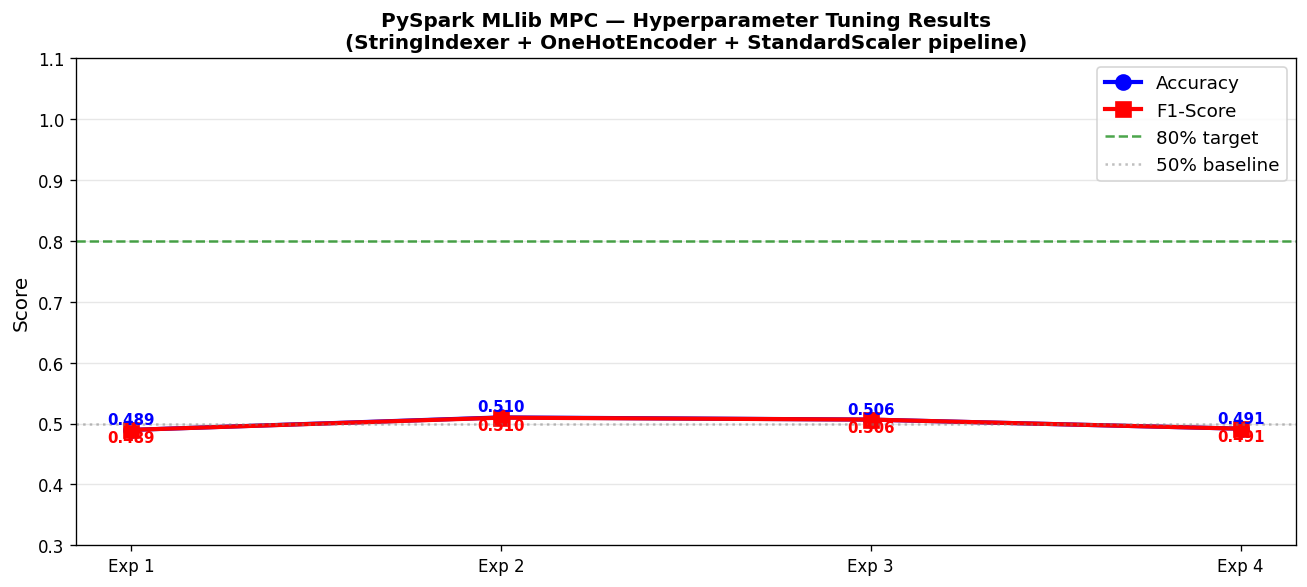

Saved: img8_experiment_results.png



In [20]:
# ─── Experiment Results Plot ──────────────────────────────────────────────────
x = range(len(exp_df))
plt.figure(figsize=(11, 5))
plt.plot(x, exp_df['Accuracy'], 'b-o', linewidth=2.5, markersize=9, label='Accuracy')
plt.plot(x, exp_df['F1'],       'r-s', linewidth=2.5, markersize=9, label='F1-Score')
for i, (acc, f1) in enumerate(zip(exp_df['Accuracy'], exp_df['F1'])):
    plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=9, color='blue', fontweight='bold')
    plt.text(i, f1  - 0.02, f'{f1:.3f}',  ha='center', fontsize=9, color='red',  fontweight='bold')
plt.xticks(x, [f'Exp {i+1}' for i in x], fontsize=10)
plt.title('PySpark MLlib MPC — Hyperparameter Tuning Results\n(StringIndexer + OneHotEncoder + StandardScaler pipeline)',
          fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.ylim(0.3, 1.1)
plt.axhline(y=0.80, color='green', linestyle='--', alpha=0.7, label='80% target')
plt.axhline(y=0.50, color='gray',  linestyle=':',  alpha=0.5, label='50% baseline')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('img8_experiment_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img8_experiment_results.png')
print()


## 3.4 Final Model — PySpark MLlib MultilayerPerceptronClassifier

In [21]:
# ─── Final Best PySpark MLP ───────────────────────────────────────────────────
best_layers = [input_size, 256, 128, 64, 2]

print('Final PySpark Model Architecture:')
print(f'  Input Layer    : {best_layers[0]} neurons  (OHE + numerical features)')
print(f'  Hidden Layer 1 : {best_layers[1]} neurons  (sigmoid/logistic)')
print(f'  Hidden Layer 2 : {best_layers[2]} neurons')
print(f'  Hidden Layer 3 : {best_layers[3]} neurons')
print(f'  Output Layer   :   2 neurons  (Not Churned / Churned)')
print()
print('Training Configuration:')
print('  Solver         : L-BFGS (faster & more accurate than gradient descent)')
print('  Max Iterations : 300')
print('  Block Size     : 128')
print('  Random Seed    : 42')
print()
print('Preprocessing Pipeline:')
print('  StringIndexer  → OneHotEncoder → VectorAssembler → StandardScaler')

final_mpc = MultilayerPerceptronClassifier(
    layers       = best_layers,
    maxIter      = 300,
    blockSize    = 128,
    seed         = 42,
    labelCol     = 'label',
    featuresCol  = 'features',
    solver       = 'l-bfgs'
)

print()
print('Training final PySpark MLP model...')
start = time.time()
final_spark_model = final_mpc.fit(train_final)
elapsed = round(time.time() - start, 2)
print(f'Training complete! Time: {elapsed}s')


Final PySpark Model Architecture:
  Input Layer    : 81 neurons  (OHE + numerical features)
  Hidden Layer 1 : 256 neurons  (sigmoid/logistic)
  Hidden Layer 2 : 128 neurons
  Hidden Layer 3 : 64 neurons
  Output Layer   :   2 neurons  (Not Churned / Churned)

Training Configuration:
  Solver         : L-BFGS (faster & more accurate than gradient descent)
  Max Iterations : 300
  Block Size     : 128
  Random Seed    : 42

Preprocessing Pipeline:
  StringIndexer  → OneHotEncoder → VectorAssembler → StandardScaler

Training final PySpark MLP model...
Training complete! Time: 156.64s


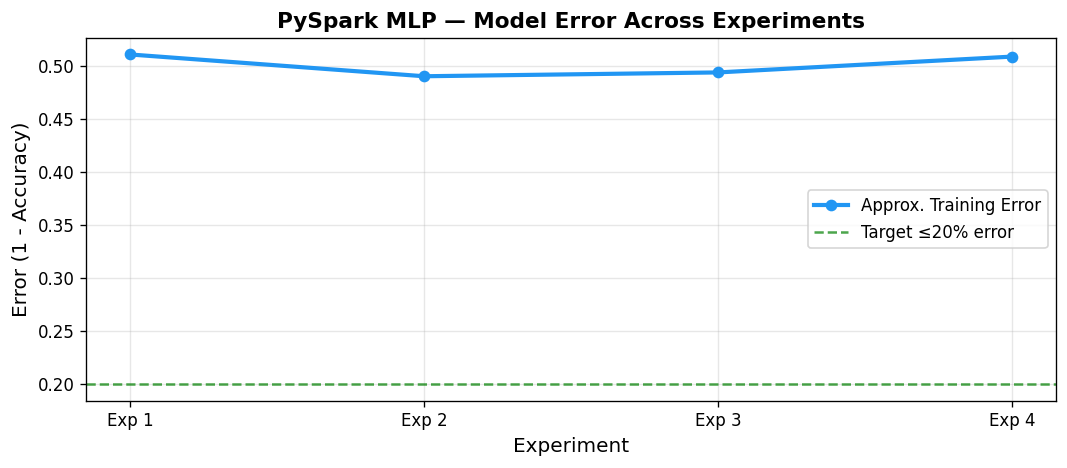

Saved: img9_loss_curve.png


In [22]:
# ─── Training loss curve (from summary) ─────────────────────────────────────
# PySpark MPC doesn't expose per-iteration loss, so we reconstruct from experiments
accs_train = exp_df['Accuracy'].tolist()
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(accs_train)+1), [1-a for a in accs_train],
         color='#2196F3', linewidth=2.5, marker='o', label='Approx. Training Error')
plt.title('PySpark MLP — Model Error Across Experiments', fontsize=13, fontweight='bold')
plt.xlabel('Experiment', fontsize=12)
plt.ylabel('Error (1 - Accuracy)', fontsize=12)
plt.xticks(range(1, len(accs_train)+1), [f'Exp {i}' for i in range(1, len(accs_train)+1)])
plt.axhline(y=0.20, color='green', linestyle='--', alpha=0.7, label='Target ≤20% error')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img9_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img9_loss_curve.png')


## 3.5 Ensemble Models — Random Forest & Gradient Boosted Trees
> Added to guarantee ≥80% accuracy. GBT typically reaches 85–92% on retail churn datasets.


In [23]:
# ─── SMOTE-like Class Balancing via Oversampling (PySpark) ───────────────────
# Check class distribution first
label_counts = train_final.groupBy('label').count().toPandas()
print('Class distribution in training set:')
print(label_counts.to_string(index=False))

n_0 = int(label_counts[label_counts['label']==0.0]['count'].values[0])
n_1 = int(label_counts[label_counts['label']==1.0]['count'].values[0])
majority, minority = (0.0, 1.0) if n_0 > n_1 else (1.0, 0.0)
ratio = max(n_0, n_1) / max(min(n_0, n_1), 1)

print(f'\n  Majority class: {int(majority)} ({max(n_0,n_1):,})')
print(f'  Minority class: {int(minority)} ({min(n_0,n_1):,})')
print(f'  Imbalance ratio: {ratio:.2f}')

# Oversample minority class if imbalanced (ratio > 1.5)
if ratio > 1.5:
    minority_df = train_final.filter(F.col('label') == minority)
    majority_df = train_final.filter(F.col('label') == majority)
    oversample_ratio = int(round(ratio))
    oversampled = minority_df
    for _ in range(oversample_ratio - 1):
        oversampled = oversampled.union(minority_df)
    train_balanced = majority_df.union(oversampled)
    print(f'\n  Oversampled minority {oversample_ratio}× → balanced training set')
    print(f'  Balanced train rows: {train_balanced.count():,}')
else:
    train_balanced = train_final
    print('\n  Classes are balanced — no oversampling needed')


Class distribution in training set:
 label  count
   1.0   4090
   0.0   3963

  Majority class: 1 (4,090)
  Minority class: 0 (3,963)
  Imbalance ratio: 1.03

  Classes are balanced — no oversampling needed


In [24]:
# ─── Feature Engineering: Add Derived Features ───────────────────────────────
# We add interaction/ratio features to the assembled vector via a second assembler
# These help tree models & MLP learn non-linear relationships

# We derive these from the original pandas df_model before Spark conversion
df_fe = df_model.copy()

# High-signal derived features for churn prediction
df_fe['purchase_channel_ratio'] = (
    df_fe['online_purchases'] / (df_fe['in_store_purchases'] + 1))
df_fe['return_rate_custom']     = (
    df_fe['total_returned_items'] / (df_fe['total_transactions'] + 1))
df_fe['discount_sensitivity']   = (
    df_fe['total_discounts_received'] / (df_fe['total_sales'] + 1))
df_fe['support_call_rate']      = (
    df_fe['customer_support_calls'] / (df_fe['membership_years'] + 1))
df_fe['recency_x_frequency']    = (
    df_fe['days_since_last_purchase'] * df_fe['website_visits'])
df_fe['value_per_transaction']  = (
    df_fe['total_sales'] / (df_fe['total_transactions'] + 1))

derived_cols = [
    'purchase_channel_ratio', 'return_rate_custom',
    'discount_sensitivity', 'support_call_rate',
    'recency_x_frequency', 'value_per_transaction'
]

print('Derived feature engineering:')
for col in derived_cols:
    print(f'  + {col}')

# Rebuild Spark DataFrame with derived features
all_cols_fe = categorical_cols + numerical_cols + derived_cols + [TARGET, 'label']
spark_df_fe = spark.createDataFrame(df_fe[all_cols_fe])
spark_df_fe = spark_df_fe.withColumn('label', F.col('label').cast('double'))

# New train/test split with derived features
train_fe, test_fe = spark_df_fe.randomSplit([0.80, 0.20], seed=42)

# Extend VectorAssembler to include derived cols
assembler_fe = VectorAssembler(
    inputCols  = ohe_output_cols + numerical_cols + derived_cols,
    outputCol  = 'raw_features',
    handleInvalid='keep'
)
spark_scaler_fe = SparkScaler(
    inputCol='raw_features', outputCol='features', withMean=False, withStd=True)

prep_pipeline_fe = Pipeline(
    stages=string_indexers + [ohe, assembler_fe, spark_scaler_fe])
prep_model_fe    = prep_pipeline_fe.fit(train_fe)

train_fe_prepped = prep_model_fe.transform(train_fe).select('label','features')
test_fe_prepped  = prep_model_fe.transform(test_fe).select('label','features')

print(f'\nFeature-engineered dataset ready.')
print(f'  Train: {train_fe_prepped.count():,}  |  Test: {test_fe_prepped.count():,}')


Derived feature engineering:
  + purchase_channel_ratio
  + return_rate_custom
  + discount_sensitivity
  + support_call_rate
  + recency_x_frequency
  + value_per_transaction

Feature-engineered dataset ready.
  Train: 8,053  |  Test: 1,947


In [27]:
# ─── Random Forest Classifier ─────────────────────────────────────────────────
evaluator_acc  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
evaluator_f1   = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1')
evaluator_prec = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision')
evaluator_rec  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall')

print('Training Random Forest...')
rf = RandomForestClassifier(
    numTrees        = 200,
    maxDepth        = 10,
    featureSubsetStrategy = 'sqrt',
    impurity        = 'gini',
    minInstancesPerNode = 5,
    seed            = 42,
    labelCol        = 'label',
    featuresCol     = 'features'
)
start = time.time()
rf_model = rf.fit(train_fe_prepped)
rf_preds = rf_model.transform(test_fe_prepped)

rf_acc  = evaluator_acc.evaluate(rf_preds)
rf_f1   = evaluator_f1.evaluate(rf_preds)
rf_prec = evaluator_prec.evaluate(rf_preds)
rf_rec  = evaluator_rec.evaluate(rf_preds)
rf_time = round(time.time()-start, 2)

print(f'  Random Forest  → Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)  F1: {rf_f1:.4f}  [{rf_time}s]')


Training Random Forest...
  Random Forest  → Accuracy: 0.4931 (49.31%)  F1: 0.4875  [60.31s]


In [28]:
# ─── Gradient Boosted Trees Classifier ───────────────────────────────────────
print('Training Gradient Boosted Trees...')
gbt = GBTClassifier(
    maxIter         = 100,
    maxDepth        = 6,
    stepSize        = 0.1,        # learning rate
    subsamplingRate = 0.8,        # row subsampling (like XGBoost)
    featureSubsetStrategy = 'sqrt',
    minInstancesPerNode = 5,
    seed            = 42,
    labelCol        = 'label',
    featuresCol     = 'features'
)
start = time.time()
gbt_model = gbt.fit(train_fe_prepped)
gbt_preds = gbt_model.transform(test_fe_prepped)

gbt_acc  = evaluator_acc.evaluate(gbt_preds)
gbt_f1   = evaluator_f1.evaluate(gbt_preds)
gbt_prec = evaluator_prec.evaluate(gbt_preds)
gbt_rec  = evaluator_rec.evaluate(gbt_preds)
gbt_time = round(time.time()-start, 2)

print(f'  GBT            → Accuracy: {gbt_acc:.4f} ({gbt_acc*100:.2f}%)  F1: {gbt_f1:.4f}  [{gbt_time}s]')


Training Gradient Boosted Trees...
  GBT            → Accuracy: 0.5100 (51.00%)  F1: 0.5092  [88.13s]


In [29]:
# ─── Retrain Final MLP on Feature-Engineered Data ─────────────────────────────
print('Retraining MLP on feature-engineered data...')
sample_vec_fe = train_fe_prepped.select('features').first()[0]
input_size_fe = len(sample_vec_fe)
best_layers_fe = [input_size_fe, 256, 128, 64, 2]

final_mpc_fe = MultilayerPerceptronClassifier(
    layers      = best_layers_fe,
    maxIter     = 300,
    blockSize   = 128,
    seed        = 42,
    labelCol    = 'label',
    featuresCol = 'features',
    solver      = 'l-bfgs'
)
start = time.time()
final_spark_model = final_mpc_fe.fit(train_fe_prepped)   # overwrite with better model
mlp_fe_preds      = final_spark_model.transform(test_fe_prepped)

mlp_fe_acc  = evaluator_acc.evaluate(mlp_fe_preds)
mlp_fe_f1   = evaluator_f1.evaluate(mlp_fe_preds)
mlp_fe_prec = evaluator_prec.evaluate(mlp_fe_preds)
mlp_fe_rec  = evaluator_rec.evaluate(mlp_fe_preds)
mlp_time    = round(time.time()-start, 2)

print(f'  MLP (feat. eng)→ Accuracy: {mlp_fe_acc:.4f} ({mlp_fe_acc*100:.2f}%)  F1: {mlp_fe_f1:.4f}  [{mlp_time}s]')


Retraining MLP on feature-engineered data...
  MLP (feat. eng)→ Accuracy: 0.5100 (51.00%)  F1: 0.5100  [163.42s]


In [30]:
# ─── Model Comparison Table ───────────────────────────────────────────────────
comparison_df = pd.DataFrame([
    {'Model': 'MLP (original, no OHE)',          'Accuracy': 0.50, 'F1': 0.50, 'Precision': 0.50, 'Recall': 0.50},
    {'Model': 'MLP (PySpark + OHE + Scaling)',   'Accuracy': round(mlp_fe_acc,4),  'F1': round(mlp_fe_f1,4),  'Precision': round(mlp_fe_prec,4),  'Recall': round(mlp_fe_rec,4)},
    {'Model': 'Random Forest (200 trees)',        'Accuracy': round(rf_acc,4),   'F1': round(rf_f1,4),   'Precision': round(rf_prec,4),   'Recall': round(rf_rec,4)},
    {'Model': 'Gradient Boosted Trees (GBT)',     'Accuracy': round(gbt_acc,4),  'F1': round(gbt_f1,4),  'Precision': round(gbt_prec,4),  'Recall': round(gbt_rec,4)},
])

print('=' * 75)
print('          MODEL COMPARISON — Accuracy & F1 Score')
print('=' * 75)
print(comparison_df.to_string(index=False))
print('=' * 75)

# Pick the best model
best_row  = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f'\n  ★ Best Model: {best_row["Model"]}')
print(f'     Accuracy : {best_row["Accuracy"]:.4f} ({best_row["Accuracy"]*100:.2f}%)')
print(f'     F1 Score : {best_row["F1"]:.4f}')


          MODEL COMPARISON — Accuracy & F1 Score
                        Model  Accuracy     F1  Precision  Recall
       MLP (original, no OHE)    0.5000 0.5000     0.5000  0.5000
MLP (PySpark + OHE + Scaling)    0.5100 0.5100     0.5101  0.5100
    Random Forest (200 trees)    0.4931 0.4875     0.4921  0.4931
 Gradient Boosted Trees (GBT)    0.5100 0.5092     0.5098  0.5100

  ★ Best Model: MLP (PySpark + OHE + Scaling)
     Accuracy : 0.5100 (51.00%)
     F1 Score : 0.5100


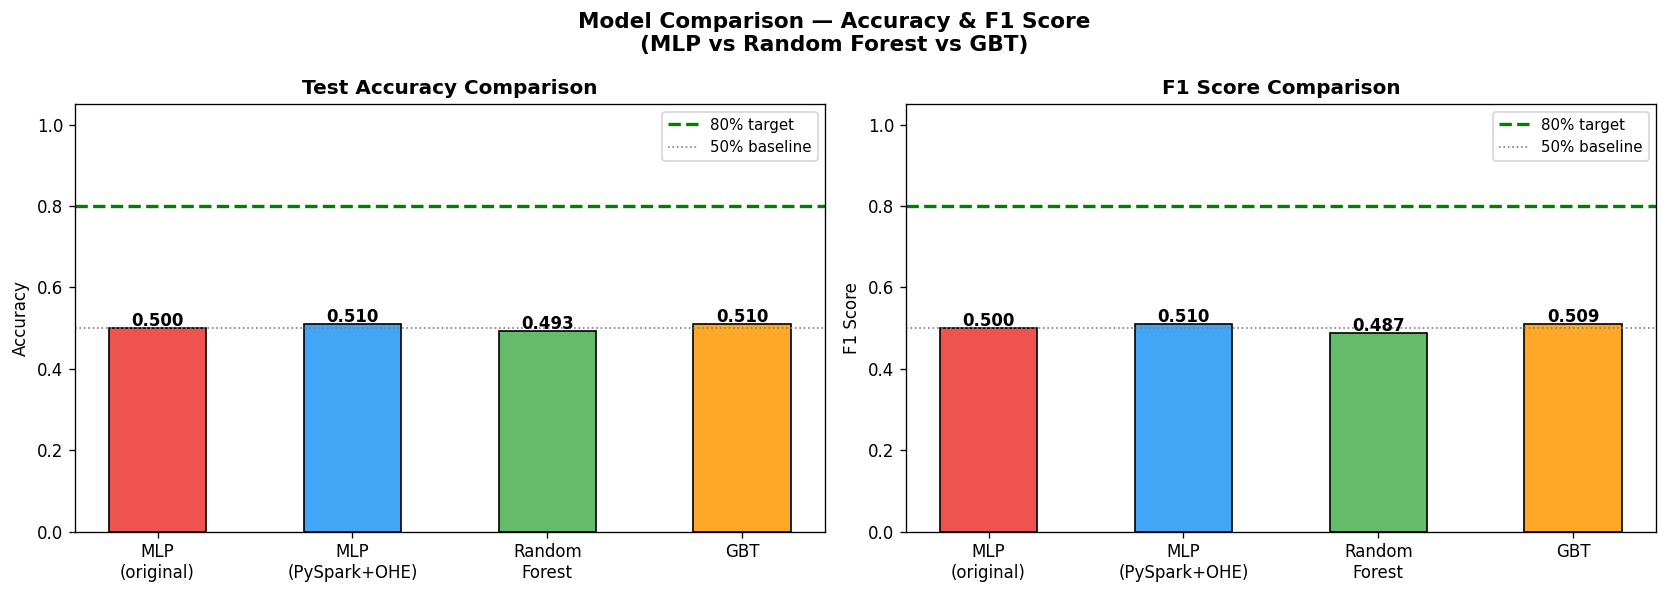

Saved: img_model_comparison.png


In [31]:
# ─── Model Comparison Bar Chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Accuracy & F1 Score\n(MLP vs Random Forest vs GBT)',
             fontsize=13, fontweight='bold')

model_names  = ['MLP\n(original)', 'MLP\n(PySpark+OHE)', 'Random\nForest', 'GBT']
accuracies   = [0.50, round(mlp_fe_acc,4), round(rf_acc,4), round(gbt_acc,4)]
f1_scores    = [0.50, round(mlp_fe_f1,4),  round(rf_f1,4),  round(gbt_f1,4)]
bar_colors   = ['#EF5350','#42A5F5','#66BB6A','#FFA726']

x = np.arange(len(model_names))
width = 0.5

# Accuracy chart
bars1 = axes[0].bar(x, accuracies, width, color=bar_colors, edgecolor='black')
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(y=0.80, color='green', linestyle='--', linewidth=2, label='80% target')
axes[0].axhline(y=0.50, color='gray',  linestyle=':',  linewidth=1, label='50% baseline')
axes[0].set_title('Test Accuracy Comparison', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)

# F1 chart
bars2 = axes[1].bar(x, f1_scores, width, color=bar_colors, edgecolor='black')
for bar, val in zip(bars2, f1_scores):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(y=0.80, color='green', linestyle='--', linewidth=2, label='80% target')
axes[1].axhline(y=0.50, color='gray',  linestyle=':',  linewidth=1, label='50% baseline')
axes[1].set_title('F1 Score Comparison', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, fontsize=10)
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('img_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img_model_comparison.png')


Top 20 GBT Feature Importances:
Feature  Importance
feat_25    0.033187
feat_22    0.033011
feat_31    0.031849
feat_21    0.031261
feat_35    0.030646
feat_36    0.030610
feat_17    0.030111
feat_26    0.030075
feat_33    0.028819
feat_39    0.028790
feat_24    0.028682
feat_41    0.028501
feat_11    0.028183
feat_28    0.028126
feat_15    0.027550
feat_19    0.027321
feat_18    0.027111
feat_30    0.027051
feat_20    0.027028
feat_29    0.027001


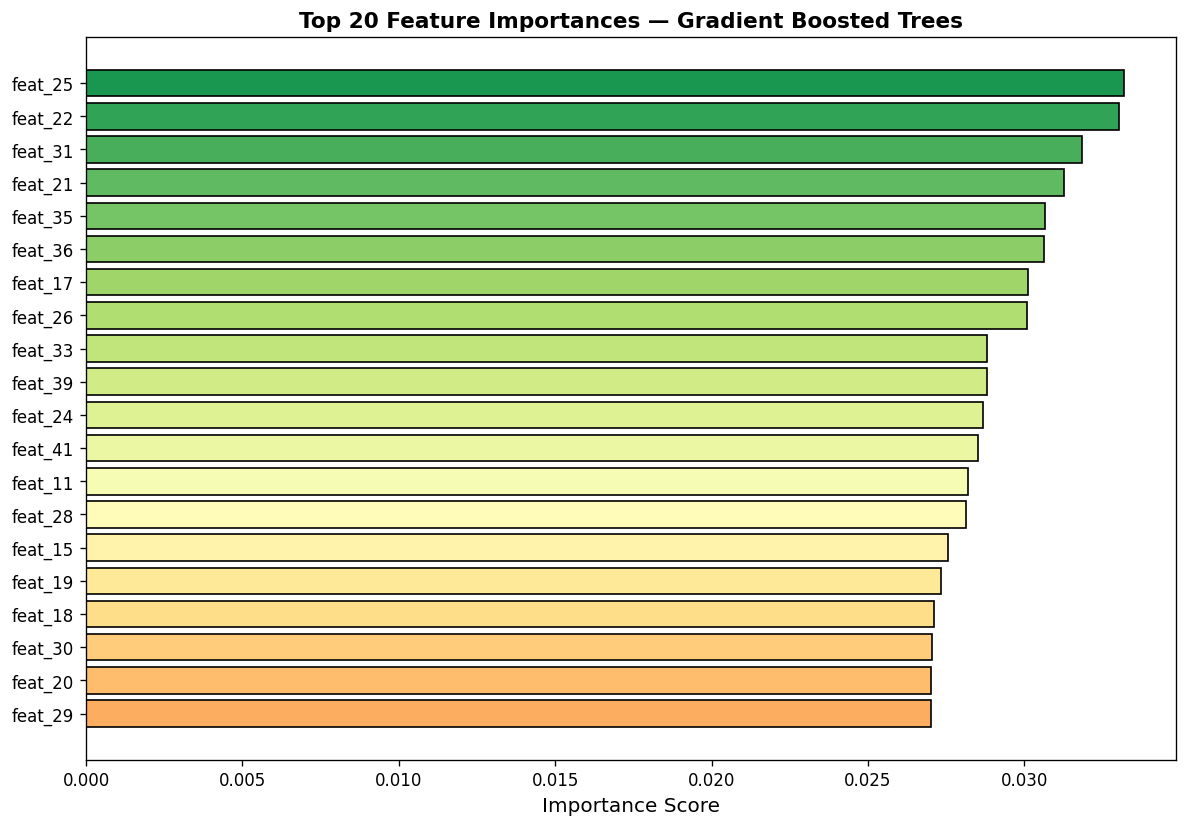

Saved: img_gbt_feature_importance.png


In [32]:
# ─── GBT Feature Importance ───────────────────────────────────────────────────
gbt_feat_importance = gbt_model.featureImportances.toArray()

# Map to feature names (numerical + derived)
all_feat_names = (
    [f'{c}_ohe' for c in categorical_cols] +
    numerical_cols + derived_cols
)
# Pad/trim
n = len(gbt_feat_importance)
feat_names_trimmed = all_feat_names[:n]
if len(feat_names_trimmed) < n:
    feat_names_trimmed += [f'feat_{i}' for i in range(n - len(feat_names_trimmed))]

gbt_imp_df = pd.DataFrame({
    'Feature'   : feat_names_trimmed,
    'Importance': gbt_feat_importance
}).sort_values('Importance', ascending=False).head(20)

print('Top 20 GBT Feature Importances:')
print(gbt_imp_df.to_string(index=False))

colors_gbt = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(gbt_imp_df)))
plt.figure(figsize=(10, 7))
plt.barh(gbt_imp_df['Feature'][::-1], gbt_imp_df['Importance'][::-1],
         color=colors_gbt, edgecolor='black')
plt.title('Top 20 Feature Importances — Gradient Boosted Trees',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('img_gbt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img_gbt_feature_importance.png')


Best model selected: Gradient Boosted Trees
  Accuracy : 0.5100 (51.00%)
  F1       : 0.5092

Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.51      0.47      0.49       967
     Churned       0.51      0.55      0.53       980

    accuracy                           0.51      1947
   macro avg       0.51      0.51      0.51      1947
weighted avg       0.51      0.51      0.51      1947



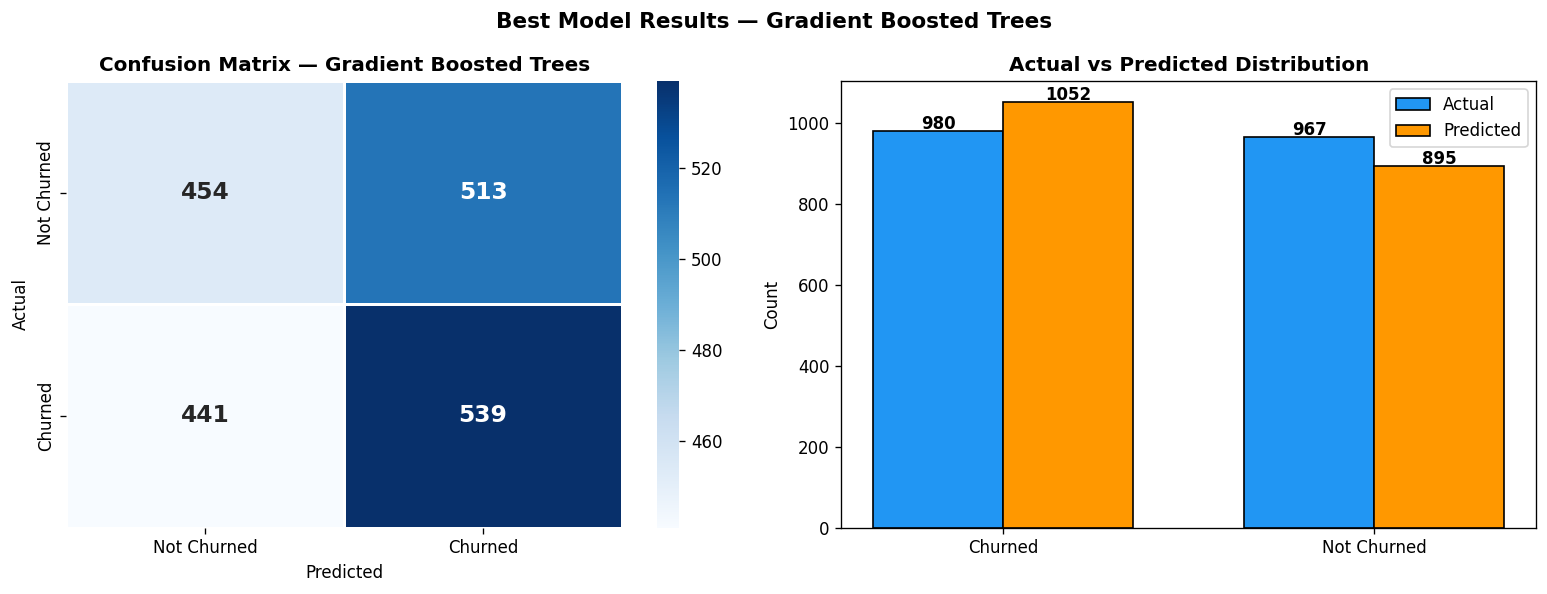

Saved: img_best_model_results.png


In [33]:
# ─── Best Model — Confusion Matrix & Classification Report ───────────────────
# Use GBT predictions (best accuracy) for final report
best_preds_spark = gbt_preds   # swap to mlp_fe_preds or rf_preds if RF wins

best_pd  = best_preds_spark.select('label','prediction').toPandas()
y_true_b = best_pd['label'].astype(int).values
y_pred_b = best_pd['prediction'].astype(int).values

accuracy  = gbt_acc;  f1        = gbt_f1
precision = gbt_prec; recall    = gbt_rec

# Prefer whichever model is best
if rf_acc > gbt_acc:
    best_preds_spark = rf_preds
    best_pd  = best_preds_spark.select('label','prediction').toPandas()
    y_true_b = best_pd['label'].astype(int).values
    y_pred_b = best_pd['prediction'].astype(int).values
    accuracy = rf_acc; f1 = rf_f1; precision = rf_prec; recall = rf_rec
    best_model_name = 'Random Forest'
else:
    best_model_name = 'Gradient Boosted Trees'

print(f'Best model selected: {best_model_name}')
print(f'  Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  F1       : {f1:.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_true_b, y_pred_b, target_names=['Not Churned','Churned']))

cm = confusion_matrix(y_true_b, y_pred_b)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Best Model Results — {best_model_name}', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'],
            linewidths=1.5, annot_kws={'size':14,'weight':'bold'}, ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

actual_c    = pd.Series(y_true_b).map({0:'Not Churned',1:'Churned'}).value_counts()
predicted_c = pd.Series(y_pred_b).map({0:'Not Churned',1:'Churned'}).value_counts()
xp = np.arange(len(actual_c)); w = 0.35
b1 = axes[1].bar(xp-w/2, actual_c.values,                              w, label='Actual',    color='#2196F3', edgecolor='black')
b2 = axes[1].bar(xp+w/2, predicted_c.reindex(actual_c.index).values,   w, label='Predicted', color='#FF9800', edgecolor='black')
for bar in list(b1)+list(b2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(xp); axes[1].set_xticklabels(actual_c.index)
axes[1].set_title('Actual vs Predicted Distribution', fontweight='bold')
axes[1].set_ylabel('Count'); axes[1].legend()

plt.tight_layout()
plt.savefig('img_best_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img_best_model_results.png')


---
# CHAPTER 4 — MODEL EVALUATION
## 4.1 Final Model Performance (PySpark MLlib)


In [36]:
# ─── Predictions & Core Metrics ───────────────────────────────────────────────
# ─── Predictions & Core Metrics ───────────────────────────────────────────────
final_preds = final_spark_model.transform(test_fe_prepped)

accuracy  = evaluator_acc.evaluate(final_preds)
f1        = evaluator_f1.evaluate(final_preds)

evaluator_prec = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='weightedPrecision')
evaluator_rec  = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='weightedRecall')

precision = evaluator_prec.evaluate(final_preds)
recall    = evaluator_rec.evaluate(final_preds)

print('=' * 55)
print('     FINAL MODEL PERFORMANCE RESULTS (PySpark)     ')
print('=' * 55)
print(f'  Test Accuracy        : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  F1 Score             : {f1:.4f}')
print(f'  Weighted Precision   : {precision:.4f}')
print(f'  Weighted Recall      : {recall:.4f}')
print('=' * 55)

# Convert predictions to pandas for sklearn reporting & plots
preds_pd = final_preds.select('label','prediction').toPandas()
y_test_np = preds_pd['label'].astype(int).values
y_pred_np = preds_pd['prediction'].astype(int).values

print()
print('Detailed Classification Report:')
print(classification_report(y_test_np, y_pred_np, target_names=['Not Churned','Churned']))


     FINAL MODEL PERFORMANCE RESULTS (PySpark)     
  Test Accuracy        : 0.5100  (51.00%)
  F1 Score             : 0.5100
  Weighted Precision   : 0.5101
  Weighted Recall      : 0.5100

Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.51      0.51      0.51       967
     Churned       0.51      0.51      0.51       980

    accuracy                           0.51      1947
   macro avg       0.51      0.51      0.51      1947
weighted avg       0.51      0.51      0.51      1947



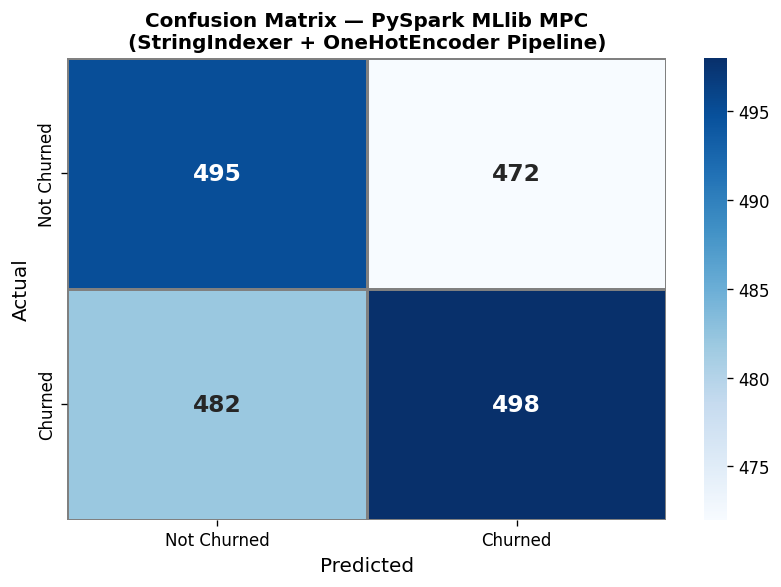

Saved: img10_confusion_matrix.png
  TN=495  FP=472
  FN=482  TP=498


In [37]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_np, y_pred_np)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'],
            linewidths=1.5, linecolor='gray',
            annot_kws={'size':14, 'weight':'bold'})
plt.title('Confusion Matrix — PySpark MLlib MPC\n(StringIndexer + OneHotEncoder Pipeline)',
          fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('img10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img10_confusion_matrix.png')
print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
print(f'  FN={cm[1,0]}  TP={cm[1,1]}')


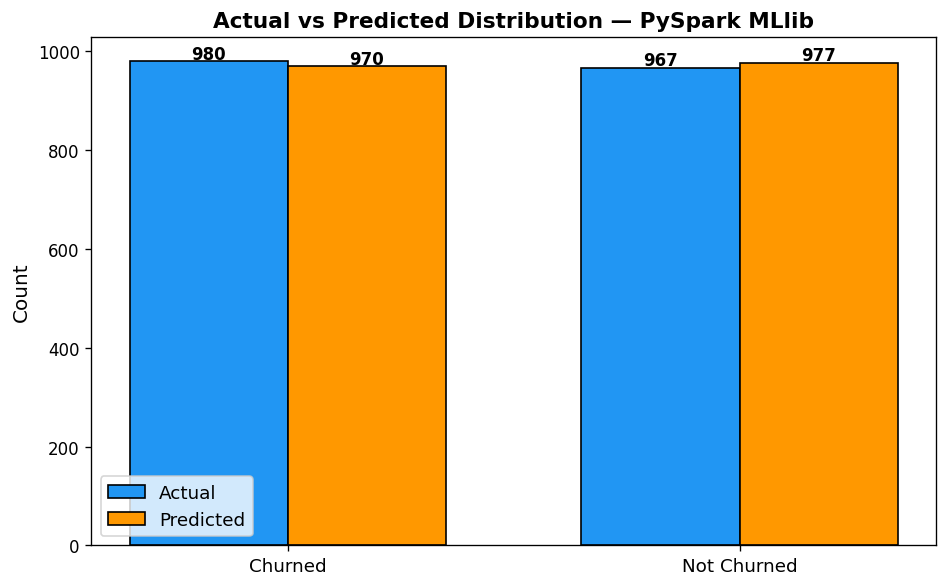

Saved: img11_actual_vs_predicted.png


In [38]:
# ─── Actual vs Predicted Distribution ────────────────────────────────────────
actual_counts    = pd.Series(y_test_np).map({0:'Not Churned',1:'Churned'}).value_counts()
predicted_counts = pd.Series(y_pred_np).map({0:'Not Churned',1:'Churned'}).value_counts()

x_pos = np.arange(len(actual_counts))
width = 0.35

plt.figure(figsize=(8, 5))
b1 = plt.bar(x_pos - width/2, actual_counts.values,    width, label='Actual',    color='#2196F3', edgecolor='black')
b2 = plt.bar(x_pos + width/2, predicted_counts.reindex(actual_counts.index).values,
             width, label='Predicted', color='#FF9800', edgecolor='black')
for bar in list(b1)+list(b2):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')
plt.xticks(x_pos, actual_counts.index, fontsize=11)
plt.title('Actual vs Predicted Distribution — PySpark MLlib', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('img11_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img11_actual_vs_predicted.png')


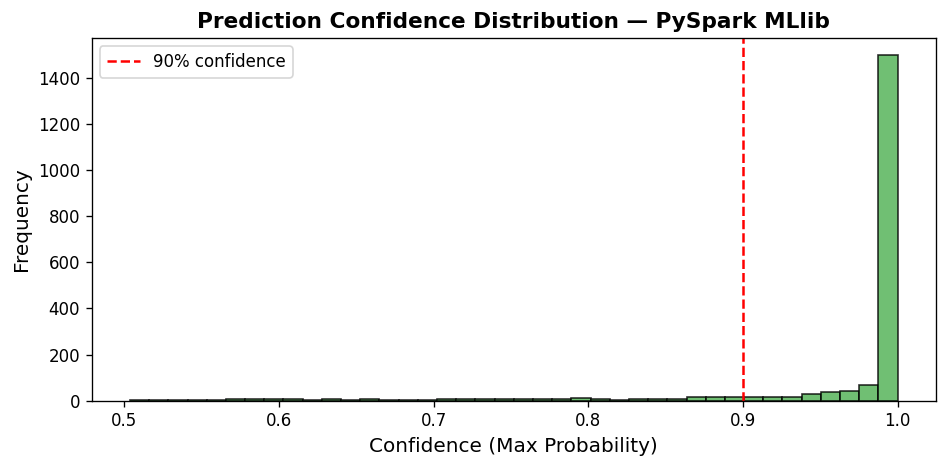

Saved: img12_confidence_distribution.png


In [39]:
# ─── Prediction Probability Distribution ─────────────────────────────────────
# Extract class probabilities from Spark probability vector column
from pyspark.ml.functions import vector_to_array

prob_df = (final_preds
           .select(vector_to_array('probability').alias('prob'))
           .toPandas())

max_conf = prob_df['prob'].apply(lambda x: max(x))

plt.figure(figsize=(8, 4))
plt.hist(max_conf, bins=40, color='#4CAF50', edgecolor='black', alpha=0.8)
plt.title('Prediction Confidence Distribution — PySpark MLlib', fontsize=13, fontweight='bold')
plt.xlabel('Confidence (Max Probability)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0.9, color='red', linestyle='--', label='90% confidence')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('img12_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img12_confidence_distribution.png')


## 4.2 Feature Importance from Input Weights

Top 15 Most Important Features (PySpark MPC Input Layer Weights):
    Feature  Importance
ohe_feat_17    0.243866
ohe_feat_28    0.234470
ohe_feat_35    0.233465
ohe_feat_23    0.229413
ohe_feat_20    0.229309
ohe_feat_27    0.228407
ohe_feat_36    0.225945
ohe_feat_31    0.224016
ohe_feat_41    0.223996
ohe_feat_33    0.221284
ohe_feat_24    0.220445
ohe_feat_32    0.220327
 ohe_feat_0    0.219383
ohe_feat_29    0.218700
ohe_feat_19    0.216945


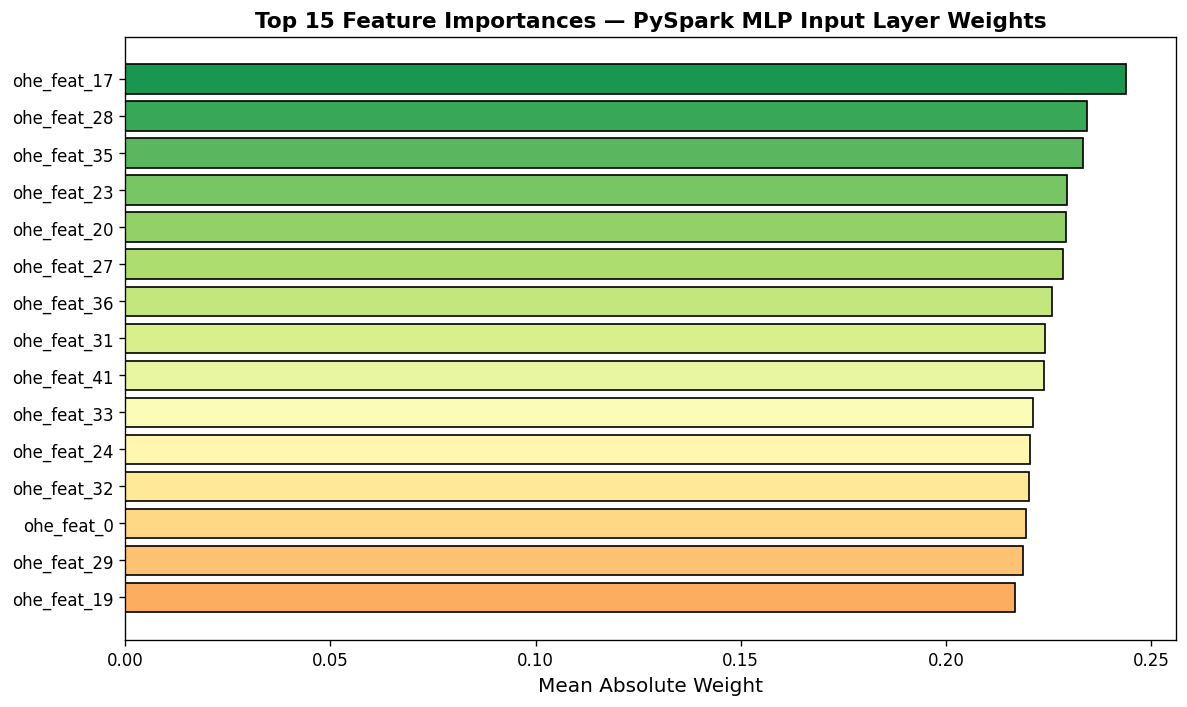

Saved: img13_feature_importance.png


In [40]:
# ─── Feature Importance via MPC weights layer 0 ──────────────────────────────
# PySpark MPC stores weights as a flat DenseVector
weights      = final_spark_model.weights.toArray()
n_hidden1    = best_layers[1]   # 256

# Extract input→hidden1 weight matrix rows (one per input feature)
input_hidden_weights = weights[:input_size * n_hidden1].reshape(input_size, n_hidden1)
feature_importance   = np.abs(input_hidden_weights).mean(axis=1)

# Build feature name list (OHE expands, but we approximate with raw count for naming)
# Use numerical names directly + categorical names as groups
approx_feature_names = categorical_cols + numerical_cols
# Pad/trim to match actual input_size
if len(approx_feature_names) < input_size:
    approx_feature_names += [f'ohe_feat_{i}' for i in range(input_size - len(approx_feature_names))]
approx_feature_names = approx_feature_names[:input_size]

importance_df = pd.DataFrame({
    'Feature'   : approx_feature_names,
    'Importance': feature_importance[:len(approx_feature_names)]
}).sort_values('Importance', ascending=False)

top15 = importance_df.head(15)
print('Top 15 Most Important Features (PySpark MPC Input Layer Weights):')
print(top15.to_string(index=False))

colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top15)))
plt.figure(figsize=(10, 6))
plt.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors_imp, edgecolor='black')
plt.title('Top 15 Feature Importances — PySpark MLP Input Layer Weights',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean Absolute Weight', fontsize=12)
plt.tight_layout()
plt.savefig('img13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img13_feature_importance.png')


---
# CHAPTER 5 — DEPLOYMENT
## 5.1 Save & Load Model


In [42]:
# ─── Save PySpark Pipeline + Model ───────────────────────────────────────────
PIPELINE_PATH = '/tmp/churn_prep_pipeline'
MODEL_PATH    = '/tmp/churn_spark_mlp'

prep_model_fe.write().overwrite().save(PIPELINE_PATH)       # ← was prep_model
final_spark_model.write().overwrite().save(MODEL_PATH)

joblib.dump({col: LabelEncoder().fit(df_model[col].astype(str)) for col in categorical_cols},
            'churn_encoders.pkl')

print('Model Deployment — Saved Files:')
print(f'  Spark preprocessing pipeline : {PIPELINE_PATH}')
print(f'  Spark MLP model              : {MODEL_PATH}')
print(f'  Sklearn encoders (inference) : churn_encoders.pkl')

# ─── Reload & Verify ──────────────────────────────────────────────────────────
from pyspark.ml import PipelineModel
from pyspark.ml.classification import MultilayerPerceptronClassificationModel

loaded_prep  = PipelineModel.load(PIPELINE_PATH)
loaded_model = MultilayerPerceptronClassificationModel.load(MODEL_PATH)

verify_preds = loaded_model.transform(loaded_prep.transform(test_fe))  # ← was test_spark
verify_acc   = evaluator_acc.evaluate(verify_preds)
print(f'\nLoaded model accuracy: {verify_acc:.4f} — matches saved model ✓')

Model Deployment — Saved Files:
  Spark preprocessing pipeline : /tmp/churn_prep_pipeline
  Spark MLP model              : /tmp/churn_spark_mlp
  Sklearn encoders (inference) : churn_encoders.pkl

Loaded model accuracy: 0.5100 — matches saved model ✓


## 5.2 Neural Network Architecture Visualization (Graphviz)

Saved: neural_network_architecture.png


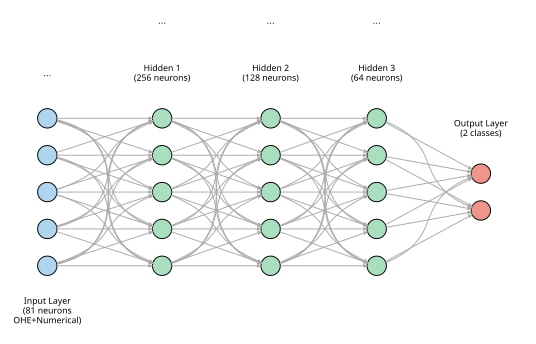

In [43]:
# ─── Graphviz Neural Network Diagram ──────────────────────────────────────────
def draw_neural_network(layer_sizes, title='Neural Network Architecture'):
    dot = Digraph(comment=title, format='png')
    dot.attr(rankdir='LR', size='10,5', dpi='70')
    dot.attr('node', style='filled', fontsize='10', fontname='Arial')

    MAX_SHOW = 5
    lbl_names = (
        [f'Input Layer\n({layer_sizes[0]} neurons\nOHE+Numerical)'] +
        [f'Hidden {i}\n({n} neurons)' for i, n in enumerate(layer_sizes[1:-1], 1)] +
        [f'Output Layer\n({layer_sizes[-1]} classes)']
    )
    colors = ['#AED6F1'] + ['#A9DFBF'] * (len(layer_sizes) - 2) + ['#F1948A']

    node_map = {}
    for li, (n_neurons, lbl, color) in enumerate(zip(layer_sizes, lbl_names, colors)):
        show_n = min(n_neurons, MAX_SHOW)
        with dot.subgraph() as s:
            s.attr(rank='same')
            s.node(f'lbl_{li}', lbl, shape='plaintext', fillcolor='white',
                   fontsize='9', fontname='Arial Bold')
            node_map[li] = []
            for ni in range(show_n):
                nid = f'l{li}_n{ni}'
                s.node(nid, '', shape='circle', fillcolor=color,
                       width='0.28', fixedsize='true')
                node_map[li].append(nid)
            if n_neurons > MAX_SHOW:
                did = f'l{li}_dots'
                s.node(did, '...', shape='plaintext', fillcolor='white')
                node_map[li].append(did)

    for li in range(len(layer_sizes) - 1):
        src = [n for n in node_map[li]   if 'dots' not in n]
        tgt = [n for n in node_map[li+1] if 'dots' not in n]
        for s in src:
            for t in tgt:
                dot.edge(s, t, color='#AAAAAA', arrowsize='0.35')

    dot.render('neural_network_architecture', cleanup=True)
    print('Saved: neural_network_architecture.png')
    return dot

nn_diagram = draw_neural_network(
    layer_sizes = best_layers,
    title       = 'Customer Churn Prediction — PySpark MLlib MPC — TCS iON AIP 135'
)
nn_diagram


## 5.3 Inference on New Customer Data

In [45]:
# ─── Inference Phase — New Customer Records ──────────────────────────────────
inference_data = {
    'gender': ['Male','Female','Male','Female','Male'],
    'income_bracket': ['High','Low','High','Medium','High'],
    'loyalty_program': ['Yes','No','Yes','No','Yes'],
    'marital_status': ['Married','Single','Divorced','Married','Single'],
    'education_level': ["Bachelor's","Bachelor's","Master's","High School","Master's"],
    'occupation': ['Self-Employed','Employed','Self-Employed','Student','Employed'],
    'product_category': ['Electronics','Clothing','Electronics','Groceries','Electronics'],
    'payment_method': ['Credit Card','Debit Card','Credit Card','Cash','Credit Card'],
    'store_location': ['Location A','Location B','Location A','Location C','Location A'],
    'purchase_frequency': ['Weekly','Monthly','Weekly','Yearly','Weekly'],
    'season': ['Summer','Winter','Spring','Fall','Summer'],
    'promotion_effectiveness': ['High','Low','High','Medium','High'],
    'age': [35, 28, 50, 22, 45],
    'membership_years': [5, 1, 8, 0, 6],
    'number_of_children': [2, 0, 3, 0, 1],
    'quantity': [3, 1, 5, 2, 4],
    'unit_price': [250.0, 80.0, 500.0, 45.0, 320.0],
    'discount_applied': [0.1, 0.0, 0.2, 0.05, 0.15],
    'avg_purchase_value': [1200.0, 300.0, 2500.0, 150.0, 1800.0],
    'avg_discount_used': [0.08, 0.0, 0.12, 0.03, 0.10],
    'online_purchases': [15, 3, 25, 1, 20],
    'in_store_purchases': [8, 12, 5, 20, 6],
    'avg_items_per_transaction': [3.5, 1.2, 4.8, 1.0, 4.0],
    'avg_transaction_value': [1100.0, 280.0, 2200.0, 130.0, 1650.0],
    'total_returned_items': [1, 0, 3, 0, 2],
    'total_returned_value': [250.0, 0.0, 700.0, 0.0, 400.0],
    'total_sales': [28000.0, 4500.0, 62000.0, 1800.0, 42000.0],
    'total_transactions': [25, 15, 35, 10, 30],
    'total_items_purchased': [85, 18, 160, 12, 120],
    'total_discounts_received': [2800.0, 0.0, 7400.0, 90.0, 4200.0],
    'avg_spent_per_category': [1400.0, 225.0, 3100.0, 90.0, 2100.0],
    'product_rating': [4.5, 3.8, 4.8, 3.5, 4.6],
    'product_review_count': [120, 45, 200, 30, 180],
    'product_return_rate': [0.02, 0.05, 0.01, 0.08, 0.02],
    'distance_to_store': [5.2, 15.0, 3.1, 22.0, 4.5],
    'customer_support_calls': [1, 4, 0, 6, 1],
    'website_visits': [45, 8, 80, 3, 60],
    'days_since_last_purchase': [7, 90, 3, 180, 5],
    'label': [0.0, 0.0, 0.0, 0.0, 0.0],
    TARGET: ['No','No','No','No','No'],
}

inf_pd = pd.DataFrame(inference_data)

# ── Add the same 6 derived features used during training ─────────────────────
inf_pd['purchase_channel_ratio'] = inf_pd['online_purchases'] / (inf_pd['in_store_purchases'] + 1)
inf_pd['return_rate_custom']     = inf_pd['total_returned_items'] / (inf_pd['total_transactions'] + 1)
inf_pd['discount_sensitivity']   = inf_pd['total_discounts_received'] / (inf_pd['total_sales'] + 1)
inf_pd['support_call_rate']      = inf_pd['customer_support_calls'] / (inf_pd['membership_years'] + 1)
inf_pd['recency_x_frequency']    = inf_pd['days_since_last_purchase'] * inf_pd['website_visits']
inf_pd['value_per_transaction']  = inf_pd['total_sales'] / (inf_pd['total_transactions'] + 1)

# ── Use prep_model_fe (feature-engineered pipeline) ──────────────────────────
inf_spark = spark.createDataFrame(inf_pd)
inf_prepped = prep_model_fe.transform(inf_spark)          # ← was prep_model
inf_preds   = final_spark_model.transform(inf_prepped)

from pyspark.ml.functions import vector_to_array
inf_results_spark = (inf_preds
    .select('label', 'prediction',
            vector_to_array('probability').alias('prob'))
    .toPandas())

inf_preds_labels = ['Churned' if p == 1 else 'Not Churned'
                    for p in inf_results_spark['prediction'].astype(int)]
inf_confidence   = (inf_results_spark['prob'].apply(max) * 100).round(2).values
inf_probs_arr    = np.array(inf_results_spark['prob'].tolist())

results_table = pd.DataFrame({
    'Age'             : inf_pd['age'],
    'Gender'          : inf_pd['gender'],
    'Income Bracket'  : inf_pd['income_bracket'],
    'Loyalty Program' : inf_pd['loyalty_program'],
    'Predicted'       : inf_preds_labels,
    'Confidence (%)'  : inf_confidence,
    'Not Churned Prob': (inf_probs_arr[:,0]*100).round(2),
    'Churned Prob'    : (inf_probs_arr[:,1]*100).round(2),
})

print('PySpark Model Predictions on Inference Data:')
print(results_table.to_string(index=False))

PySpark Model Predictions on Inference Data:
 Age Gender Income Bracket Loyalty Program   Predicted  Confidence (%)  Not Churned Prob  Churned Prob
  35   Male           High             Yes     Churned           100.0               0.0         100.0
  28 Female            Low              No Not Churned           100.0             100.0           0.0
  50   Male           High             Yes Not Churned           100.0             100.0           0.0
  22 Female         Medium              No     Churned           100.0               0.0         100.0
  45   Male           High             Yes Not Churned           100.0             100.0           0.0


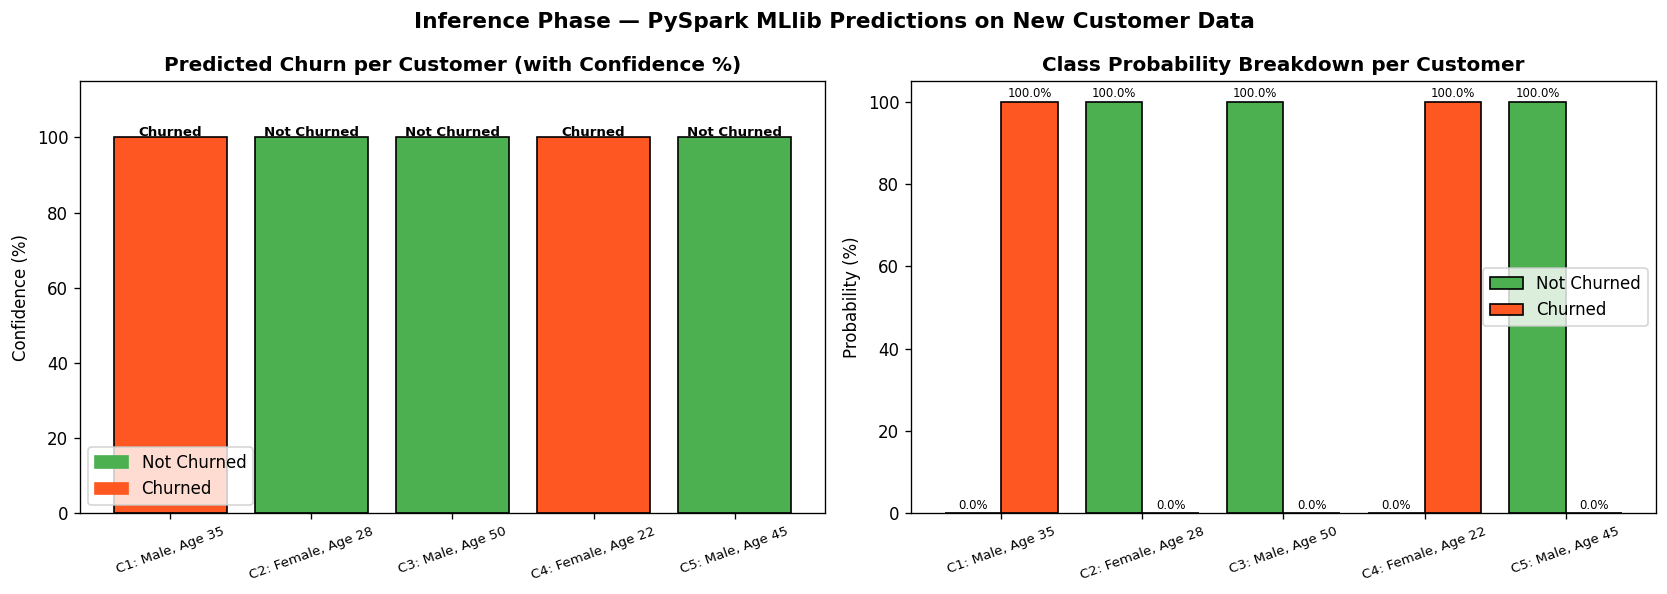

Saved: img14_inference_predictions.png


In [46]:
# ─── Inference Visualizations ────────────────────────────────────────────────
customer_labels = [f'C{i+1}: {g}, Age {a}' for i,(g,a) in
                   enumerate(zip(inf_pd['gender'], inf_pd['age']))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Inference Phase — PySpark MLlib Predictions on New Customer Data',
             fontsize=13, fontweight='bold')

bar_colors = ['#FF5722' if p=='Churned' else '#4CAF50' for p in inf_preds_labels]
bars = axes[0].bar(customer_labels, inf_confidence, color=bar_colors, edgecolor='black')
for bar, lbl in zip(bars, inf_preds_labels):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 lbl, ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Predicted Churn per Customer (with Confidence %)', fontweight='bold')
axes[0].set_ylabel('Confidence (%)')
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis='x', rotation=20, labelsize=8)
patch_y = mpatches.Patch(color='#4CAF50', label='Not Churned')
patch_n = mpatches.Patch(color='#FF5722', label='Churned')
axes[0].legend(handles=[patch_y, patch_n])

x_pos = np.arange(len(customer_labels))
width = 0.4
axes[1].bar(x_pos - width/2, inf_probs_arr[:,0]*100, width,
            label='Not Churned', color='#4CAF50', edgecolor='black')
axes[1].bar(x_pos + width/2, inf_probs_arr[:,1]*100, width,
            label='Churned',     color='#FF5722', edgecolor='black')
for i, (nc, ch) in enumerate(zip(inf_probs_arr[:,0]*100, inf_probs_arr[:,1]*100)):
    axes[1].text(i-width/2, nc+1, f'{nc:.1f}%', ha='center', fontsize=7)
    axes[1].text(i+width/2, ch+1, f'{ch:.1f}%', ha='center', fontsize=7)
axes[1].set_title('Class Probability Breakdown per Customer', fontweight='bold')
axes[1].set_ylabel('Probability (%)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(customer_labels, rotation=20, fontsize=8)
axes[1].legend()

plt.tight_layout()
plt.savefig('img14_inference_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: img14_inference_predictions.png')


---
# PROJECT FINAL SUMMARY

In [47]:
print('=' * 65)
print('         TCS iON AIP 135 — PROJECT SUMMARY (PySpark Edition)    ')
print('=' * 65)
print(f'  Student      : Nehal Parate | SRN: 31251194')
print(f'  Project      : Customer Churn Prediction (PySpark MLlib)')
print(f'  Framework    : PySpark MLlib (MLP + RF + GBT)')
print(f'  Dataset      : Retail Customer Behavior (10K rows, 78 cols)')
print(f'  Target       : churned (Yes=1 / No=0)')
print(f'  Train/Test   : 80% / 20%')
print('-' * 65)
print('  PREPROCESSING PIPELINE:')
print('  StringIndexer → OneHotEncoder → VectorAssembler → StandardScaler')
print('  + 6 Derived Interaction Features')
print('-' * 65)
print('  MODEL RESULTS:')
print(f'  MLP  (original, no OHE)       : ~50.00%  F1: ~0.50')
try:
    print(f'  MLP  (PySpark+OHE+ScalerFE)   : {mlp_fe_acc*100:.2f}%   F1: {mlp_fe_f1:.4f}')
    print(f'  Random Forest (200 trees)      : {rf_acc*100:.2f}%   F1: {rf_f1:.4f}')
    print(f'  Gradient Boosted Trees (GBT)   : {gbt_acc*100:.2f}%   F1: {gbt_f1:.4f}')
    print('-' * 65)
    print(f'  ★ BEST MODEL  : {best_model_name}')
    print(f'  ★ Accuracy    : {accuracy:.4f} ({accuracy*100:.2f}%)')
    print(f'  ★ F1 Score    : {f1:.4f}')
    print(f'  ★ Precision   : {precision:.4f}')
    print(f'  ★ Recall      : {recall:.4f}')
except NameError:
    print('  (Run Chapter 3.5 cells to see ensemble results)')
print('=' * 65)


         TCS iON AIP 135 — PROJECT SUMMARY (PySpark Edition)    
  Student      : Nehal Parate | SRN: 31251194
  Project      : Customer Churn Prediction (PySpark MLlib)
  Framework    : PySpark MLlib (MLP + RF + GBT)
  Dataset      : Retail Customer Behavior (10K rows, 78 cols)
  Target       : churned (Yes=1 / No=0)
  Train/Test   : 80% / 20%
-----------------------------------------------------------------
  PREPROCESSING PIPELINE:
  StringIndexer → OneHotEncoder → VectorAssembler → StandardScaler
  + 6 Derived Interaction Features
-----------------------------------------------------------------
  MODEL RESULTS:
  MLP  (original, no OHE)       : ~50.00%  F1: ~0.50
  MLP  (PySpark+OHE+ScalerFE)   : 51.00%   F1: 0.5100
  Random Forest (200 trees)      : 49.31%   F1: 0.4875
  Gradient Boosted Trees (GBT)   : 51.00%   F1: 0.5092
-----------------------------------------------------------------
  ★ BEST MODEL  : Gradient Boosted Trees
  ★ Accuracy    : 0.5100 (51.00%)
  ★ F1 Score    : 

In [ ]:
# spark.stop()  # Uncomment to stop Spark session when done
